### 전처리

In [1]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 데이터 처리 및 분석
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import warnings

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from scipy.stats import skew, kurtosis
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg
import scikit_posthocs as sp

# 머신러닝
from sklearn.preprocessing import MinMaxScaler

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 참고: seed 고정으로 팀원 간 동일한 결과 재현 가능
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


# 1. 데이터 로드

- metadata.csv 파일을 불러오는 첫 단계
- 총 7,565행, 34개 배터리 데이터  
- charge (충전), discharge (방전), impedance (내부저항)

In [2]:
import pandas as pd
import os

# 경로 설정
base_path = "data"  # 프로젝트 기준
meta_path = os.path.join(base_path, r"C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\metadata.csv")

# metadata 불러오기
df = pd.read_csv(meta_path)

# 확인
print(df.shape)
df.head()

(7565, 10)


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


# 2. start_time 전처리 

In [3]:
import pandas as pd

def clear_time(x):
    # 결측치 처리
    if pd.isna(x):
        return pd.NaT
    
    # 문자열로 변환
    x = str(x)

    nums = []
    current = ''

    # 숫자 관련 문자만 추출
    for ch in x:
        if ch.isdigit() or ch in ['.', 'e', 'E', '+', '-']:
            current += ch
        else:
            if current != '':
                nums.append(current)
                current = ''

    if current != '':
        nums.append(current)

    # 연월일시분초 최소 6개 필요
    if len(nums) < 6:
        return pd.NaT

    try:
        nums = list(map(float, nums[:6]))
    except:
        return pd.NaT

    year, month, day, hour, minute, second = nums

    # 범위 체크
    if not (2000 <= year <= 2100 and
            1 <= month <= 12 and
            1 <= day <= 31 and
            0 <= hour < 24 and
            0 <= minute < 60 and
            0 <= second < 60):
        return pd.NaT

    try:
        return pd.Timestamp(
            int(year), int(month), int(day),
            int(hour), int(minute), int(second)
        )
    except:
        return pd.NaT


df['start_time'] = df['start_time'].apply(clear_time)
df = df.dropna(subset=['start_time'])

### 2-1. 시간 파생 칼럼 생성
- elapsed_hours_from_first 생성 : 첫 가동 후 경과 시간 = 전체 생애 주기 상 어느 지점에 있는지 파악 가능
- rest_hours_from_prev_discharge 생성 : 방전 후 휴지 시간 = 충분한 휴지시간을 가졌는지에 따라 전압 회복 정도가 달라짐

In [4]:
# 1. 시간 순으로 정렬 (배터리 ID와 시작 시간 기준)
df = df.sort_values(by=['battery_id', 'start_time']).reset_index(drop=True)

# 2. elapsed_hours_from_first 생성
# 배터리별로 첫 번째 start_time을 뺀 후, 시간(hours) 단위로 변환
df['elapsed_hours_from_first'] = df.groupby('battery_id')['start_time'].transform(
    lambda x: (x - x.min()).dt.total_seconds() / 3600
)

# 3. rest_hours_from_prev_discharge 생성
# 이전 행의 start_time을 활용, '이전 작업의 시작 시간'과의 차이를 계산
# 휴지기 + 작업시간
df['rest_hours_from_prev_discharge'] = df.groupby('battery_id')['start_time'].diff().dt.total_seconds() / 3600

# 첫 번째 데이터는 이전 데이터가 없으므로 0 또는 결측치 처리
df['rest_hours_from_prev_discharge'] = df['rest_hours_from_prev_discharge'].fillna(0)


# 3. 그룹 컬럼 추가

- 배터리 34개를 README 기준으로 A~I 9개 그룹으로 묶음.
- 그룹마다 온도·전류·종료 방식이 다르기 때문에 나눠서 관리
- group: 실험 조건이 같은 배터리 묶음A, B, C ... I
- end_reason: 실험이 왜 끝났는가EOL(수명 다함), crashed(크래시), censored(사이클 부족)
- analysis_role: 이 그룹을 어디에 쓸지 main(핵심), comparison(비교), anomaly(이상탐지), excluded(제외)


In [5]:
# 그룹 매핑 (A~I)
group_map = {
    'B0005':'A','B0006':'A','B0007':'A','B0018':'A',
    'B0025':'B','B0026':'B','B0027':'B','B0028':'B',
    'B0029':'C','B0030':'C','B0031':'C','B0032':'C',
    'B0033':'D','B0034':'D','B0036':'D',
    'B0038':'E','B0039':'E','B0040':'E',
    'B0041':'F','B0042':'F','B0043':'F','B0044':'F',
    'B0045':'G','B0046':'G','B0047':'G','B0048':'G',
    'B0049':'H','B0050':'H','B0051':'H','B0052':'H',
    'B0053':'I','B0054':'I','B0055':'I','B0056':'I',
}
 
# 종료 사유 매핑
# EOL      : 정상 수명 종료
# censored : EOL 미달 (사이클 부족)
# crashed  : SW 크래시로 실험 강제 중단
# QA_issue : 데이터 품질 문제 (조건 변경, 초기값 비정상)
end_reason_map = {
    'A': 'EOL',
    'B': 'censored',
    'C': 'censored',
    'D': 'QA_issue',
    'E': 'QA_issue',
    'F': 'QA_issue',
    'G': 'QA_issue',
    'H': 'crashed',
    'I': 'QA_issue',
}
 
# 그룹별 실험 조건 (프로토콜 매트릭스)
group_info = {
    'A': {'온도':'실온',    '방전전류':'2A CC',      'cutoff':'2.7/2.5/2.2/2.5V', '신뢰도':'정상'},
    'B': {'온도':'24°C',   '방전전류':'4A 스퀘어파', 'cutoff':'2.0~2.7V',          '신뢰도':'주의'},
    'C': {'온도':'43°C',   '방전전류':'4A',          'cutoff':'2.0~2.7V',          '신뢰도':'주의'},
    'D': {'온도':'24°C',   '방전전류':'4A/2A 혼합',  'cutoff':'2.0~2.7V',          '신뢰도':'비정상'},
    'E': {'온도':'24&44°C','방전전류':'1/2/4A 복합', 'cutoff':'2.2~2.7V',          '신뢰도':'비정상'},
    'F': {'온도':'4°C',    '방전전류':'4A/1A 혼합',  'cutoff':'2.0~2.7V',          '신뢰도':'비정상'},
    'G': {'온도':'4°C',    '방전전류':'1A',          'cutoff':'2.0~2.7V',          '신뢰도':'비정상'},
    'H': {'온도':'4°C',    '방전전류':'2A',          'cutoff':'2.0~2.7V',          '신뢰도':'심각'},
    'I': {'온도':'4°C',    '방전전류':'2A',          'cutoff':'2.0~2.7V',          '신뢰도':'비정상'},
}
 
# 분석 역할 매핑
analysis_role_map = {
    'A': 'main',        # 핵심 분석
    'B': 'excluded',    # 사이클 부족 제외
    'C': 'comparison',  # 온도 비교용
    'D': 'excluded',    # 초기값 비정상 제외
    'E': 'excluded',    # 조건 변경 복잡 제외
    'F': 'anomaly',     # 이상탐지 활용
    'G': 'anomaly',
    'H': 'anomaly',
    'I': 'anomaly',
}
 
df['group']        = df['battery_id'].map(group_map)
df['end_reason']   = df['group'].map(end_reason_map)
df['analysis_role']= df['group'].map(analysis_role_map)
 
print("\n그룹별 배터리 수 및 역할:")
summary = df.groupby(['group','end_reason','analysis_role'])['battery_id'].nunique().reset_index()
summary.columns = ['group','end_reason','analysis_role','배터리수']
print(summary.to_string(index=False))
 


그룹별 배터리 수 및 역할:
group end_reason analysis_role  배터리수
    A        EOL          main     4
    B   censored      excluded     4
    C   censored    comparison     4
    D   QA_issue      excluded     3
    E   QA_issue      excluded     3
    F   QA_issue       anomaly     4
    G   QA_issue       anomaly     4
    H    crashed       anomaly     4
    I   QA_issue       anomaly     4


In [6]:
# 기존 group_map 아래에 이것만 추가하면 됩니당

ambient_profile_map = {
    'A': '24°C_stable',
    'B': '24°C_stable',
    'C': '43°C_stable',
    'D': '24°C_stable',
    'E': '24_44°C_mixed',
    'F': '4°C_stable',
    'G': '4°C_stable',
    'H': '4°C_stable',
    'I': '4°C_stable',
}

load_profile_map = {
    'A': '2A_CC',
    'B': '4A_squarewave',
    'C': '4A_CC',
    'D': '2A_4A_mixed',
    'E': '1A_2A_4A_mixed',
    'F': '4A_1A_mixed',
    'G': '1A_CC',
    'H': '2A_CC',
    'I': '2A_CC',
}

cutoff_voltage_map = {
    'A': 2.7,
    'B': 2.7,
    'C': 2.7,
    'D': 2.5,
    'E': 2.5,
    'F': 2.7,
    'G': 2.7,
    'H': 2.7,
    'I': 2.7,
}

eol_rule_source_map = {
    'A': 'NASA_30%fade',
    'B': 'censored',
    'C': 'censored',
    'D': 'NASA_20%fade',
    'E': 'NASA_20%fade',
    'F': 'NASA_30%fade',
    'G': 'NASA_30%fade',
    'H': 'crashed',
    'I': 'NASA_30%fade',
}

# 기존 df['group'] = ... 아래에 추가하시면 됩니다
df['ambient_profile']  = df['group'].map(ambient_profile_map)
df['load_profile']     = df['group'].map(load_profile_map)
df['cutoff_voltage']   = df['group'].map(cutoff_voltage_map)
df['eol_rule_source']  = df['group'].map(eol_rule_source_map)

원본 데이터는 충전·방전·임피던스가 한 테이블에 섞여 있음.
각 타입마다 의미 있는 컬럼이 다르기 때문에 반드시 분리

In [7]:
df_charge    = df[df['type'] == 'charge'].copy()
df_discharge = df[df['type'] == 'discharge'].copy()
df_impedance = df[df['type'] == 'impedance'].copy()
 
print("\n" + "=" * 55)
print("타입별 분리 완료")
print("=" * 55)
print(f"df_charge    : {len(df_charge):,}행")
print(f"df_discharge : {len(df_discharge):,}행")
print(f"df_impedance : {len(df_impedance):,}행")


타입별 분리 완료
df_charge    : 2,815행
df_discharge : 2,794행
df_impedance : 1,956행


# 4. Capacity 상태 flag 추가

Capacity 값을 5가지 상태로 분류

# flag 의미처리 방법

- valid: 정상값 (0.3 ~ 2.1Ah)분석에 사용
- zero: 정확히 0이상값으로 처리
- missing: NaN (빈 값)결측치로 처리
- low_anomaly0: 초과 0.3Ah 미만이상값 후보 (조건 변경 가능성 검토)
- impossible_high: 2.1Ah 초과 물리적으로 불가능한 값

In [8]:
df_discharge['Capacity'] = pd.to_numeric(
    df_discharge['Capacity'], errors='coerce'
)
 
def classify_capacity(cap):
    if pd.isna(cap):
        return 'missing'
    elif cap == 0:
        return 'zero'
    elif cap > 2.1:
        return 'impossible_high'
    elif cap < 0.3:
        return 'low_anomaly'
    else:
        return 'valid'
 
df_discharge['cap_flag'] = df_discharge['Capacity'].apply(classify_capacity)
 
hard_exclude = ['missing', 'zero', 'impossible_high']
df_discharge['cap_exclude'] = df_discharge['cap_flag'].isin(hard_exclude)        # 하드 제외 후보
df_discharge['cap_anomaly'] = df_discharge['cap_flag'] == 'low_anomaly'          # 이상탐지 대시보드용


print("\n" + "=" * 55)
print("Capacity flag 분포 (전체)")
print("=" * 55)
print(df_discharge['cap_flag'].value_counts())

print("\n하드 제외 후보:", df_discharge['cap_exclude'].sum())
print("이상탐지 대상:", df_discharge['cap_anomaly'].sum())
 
print("\n그룹별 flag 분포:")
flag_grp = (
    df_discharge.groupby(['group','cap_flag'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
print(flag_grp.to_string(index=False))


Capacity flag 분포 (전체)
cap_flag
valid              2553
low_anomaly         193
missing              25
zero                 19
impossible_high       4
Name: count, dtype: int64

하드 제외 후보: 48
이상탐지 대상: 193

그룹별 flag 분포:
group  impossible_high  low_anomaly  missing  valid  zero
    A                0            0        0    636     0
    B                0            0        0    112     0
    C                0            0        0    160     0
    D                1            6        0    584     0
    E                0            2        0    139     0
    F                0          180        0    220     3
    G                0            0        0    277    11
    H                3            5       25     64     3
    I                0            0        0    361     2


### 4-1. Impedanve 상태 flag 추가
Capacity 값을 5가지 상태로 분류

### flag 의미처리 방법
- valid / 정상 범위 내 저항값 / 분석 및 모델 학습 / 분류 구분
- missing / NaN (빈 값) / 보간(Interpolation) 또는 해당 행 제외 / 정상 데이터
- zero_or_minus / 0 이하의 값(물리적 오류) / 측정 오류로 간주하여 분석 제외 / 하드 제외
- low_anomaly / 임계값 초과 / 열화가 극심하거나 접촉 불량일 가능성 (검토 필요) / 하드 제외
& 수명 종료 시점 감지의 조기 경보 지표로 활용 / 하드 제외
- noise_candidate / 2직전 측정 대비 급격한 튀는 값 / 평활화(Smoothing) 처리 고려 → 노이즈 제거 / 이상 탐지
- rct_imbalance / Re에 비해 Rct가 비정상적으로 큼 / 충전 거동 이상 및 내부 화학 반응 모니터링 / 이상 탐지

In [9]:
# 1. 수치형 변환 및 정렬 (시계열 비교를 위해 필수)
df_impedance['Re'] = pd.to_numeric(df_impedance['Re'], errors='coerce')
df_impedance['Rct'] = pd.to_numeric(df_impedance['Rct'], errors='coerce')
df_impedance = df_impedance.sort_values(['battery_id', 'start_time']).reset_index(drop=True)

# 2. 직전 측정값과의 차이 계산 (noise_candidate 판별용)
# 배터리별로 바로 이전 행의 Re 값과의 차이를 구합니다.
df_impedance['re_diff'] = df_impedance.groupby('battery_id')['Re'].diff().abs()

def classify_impedance(row):
    re, rct, diff = row['Re'], row['Rct'], row['re_diff']

    # [하드 제외] 결측치
    if pd.isna(re) or pd.isna(rct):
        return 'missing'

    # [하드 제외] 물리적 오류
    if re <= 0 or rct <= 0:
        return 'zero_or_minus'

    # [이상 탐지] 통계적 노이즈 (직전 대비 0.3 이상 급격히 튈 때 - 기준은 데이터에 따라 조정 가능)
    if pd.notna(diff) and diff > 0.3:
        return 'noise_candidate'

    # [이상 탐지] 구조적 불균형 (Rct가 Re의 10배를 초과할 때)
    if rct > re * 10:
        return 'rct_imbalance'

    # [이상 탐지] 임계값 초과 (극심한 열화)
    if re > 1.0 or rct > 1.5:
        return 'high_anomaly'

    return 'valid'

# 3. 플래그 적용
df_impedance['imp_flag'] = df_impedance.apply(classify_impedance, axis=1)

# 4. 분석 용도별 칼럼 추가 (튜터님 피드백 반영)
hard_exclude_imp = ['missing', 'zero_or_minus']
df_impedance['imp_exclude'] = df_impedance['imp_flag'].isin(hard_exclude_imp)

anomaly_imp = ['high_anomaly', 'noise_candidate', 'rct_imbalance']
df_impedance['imp_anomaly'] = df_impedance['imp_flag'].isin(anomaly_imp)

# 5. 결과 확인
print("=" * 55)
print("Impedance Flag 분포 결과")
print("=" * 55)
print(df_impedance['imp_flag'].value_counts())

print(f"\n하드 제외 대상: {df_impedance['imp_exclude'].sum()}건")
print(f"이상 탐지 대상: {df_impedance['imp_anomaly'].sum()}건")

# 그룹별 요약 보고서
imp_summary = df_impedance.groupby(['group', 'imp_flag']).size().unstack(fill_value=0)
print("\n[그룹별 상세 분포]")
print(imp_summary)

Impedance Flag 분포 결과
imp_flag
valid              1932
zero_or_minus        11
missing               9
noise_candidate       4
Name: count, dtype: int64

하드 제외 대상: 20건
이상 탐지 대상: 4건

[그룹별 상세 분포]
imp_flag  missing  noise_candidate  valid  zero_or_minus
group                                                   
A               0                0    887              0
B               0                0     84              0
C               0                0     68              0
D               0                0    276              0
E               0                0     84              0
F               0                0    179              0
G               0                0    160              0
H               9                4     24             11
I               0                0    170              0


## 5. discharge 사이클 순번 추가

각 배터리별 방전 기록에 순번을 붙임.

- `discharge_cycle_raw` : 전체 기록 기준 순번
- `discharge_cycle_valid` : hard exclusion 제외 후 순번

예:
- B0005 첫 방전이 정상 → `raw = 1`, `valid = 1`
- B0005 두 번째 방전이 missing → `raw = 2`, `valid = NaN`
- B0005 세 번째 방전이 정상 → `raw = 3`, `valid = 2`

In [10]:
# df_discharge = df_discharge.sort_values(['battery_id','test_id'])
# df_discharge['discharge_cycle_no'] = (
#     df_discharge.groupby('battery_id').cumcount() + 1
# ) #기존코드, discharge_cycle_no쓰이는 부분 바꿔야함

In [11]:
# 1. battery별 시간 순서대로 discharge 데이터를 정렬
# start_time이 먼저, 같은 시간이면 filename으로 한 번 더 정렬
df_discharge = df_discharge.sort_values(
    ['battery_id', 'start_time', 'filename']
).reset_index(drop=True)

# 2. 전체 discharge 시도 기준 cycle 번호 생성
# 정상/이상 데이터를 따지기 전에, 실제 발생한 discharge 기록의 순서 자체를 먼저 매긴다
df_discharge['discharge_cycle_raw'] = (
    df_discharge.groupby('battery_id').cumcount() + 1
)

# 3. hard exclusion 여부 생성
# missing, zero, impossible_high 는 모델링/핵심 분석에서 제외할 강한 품질 문제로 간주
df_discharge['is_hard_excluded'] = df_discharge['cap_flag'].isin(
    ['missing', 'zero', 'impossible_high']
)

# 4. valid discharge cycle 번호 생성
# hard exclusion이 아닌 행만 대상으로 다시 1, 2, 3 ... 번호 부여
# hard exclusion 행은 자동으로 NaN으로 남음
df_discharge['discharge_cycle_valid'] = (
    df_discharge.loc[~df_discharge['is_hard_excluded']]
    .groupby('battery_id')
    .cumcount() + 1
)

6. 초기 Capacity 계산

각 배터리의 처음 상태(기준값)을 구함.
SOH 계산에 꼭 필요!

- 첫 번째 사이클 값 단독 사용 금지
- B0041처럼 초반에 실험 조건이 달라서 값이 비정상으로 낮은 경우가 있음.그래서 valid한 값 중 앞 5개의 중앙값으로 계산.

In [12]:
init_cap = (
    df_discharge[df_discharge['cap_flag'] == 'valid']
    .groupby('battery_id')['Capacity']
    .apply(lambda x: x.head(5).median())
    .rename('init_cap')
)
 
df_discharge = df_discharge.merge(init_cap, on='battery_id', how='left')
 
print("\n" + "=" * 55)
print("초기 Capacity (valid 구간 첫 5개 중앙값)")
print("=" * 55)
init_summary = df_discharge.groupby(['battery_id','group'])['init_cap'].first().reset_index()
print(init_summary.round(4).to_string(index=False))
 


초기 Capacity (valid 구간 첫 5개 중앙값)
battery_id group  init_cap
     B0005     A    1.8353
     B0006     A    2.0133
     B0007     A    1.8807
     B0018     A    1.8396
     B0025     B    1.8471
     B0026     B    1.8143
     B0027     B    1.8142
     B0028     B    1.7976
     B0029     C    1.8158
     B0030     C    1.7518
     B0031     C    1.8044
     B0032     C    1.8655
     B0033     D    1.2529
     B0034     D    1.6207
     B0036     D    1.8011
     B0038     E    1.0613
     B0039     E    0.4711
     B0040     E    0.7796
     B0041     F    1.1195
     B0042     F    1.7282
     B0043     F    1.6815
     B0044     F    1.6534
     B0045     G    0.8852
     B0046     G    1.5031
     B0047     G    1.5081
     B0048     G    1.4989
     B0049     H    1.3644
     B0050     H    1.5518
     B0051     H    1.2039
     B0052     H    1.3611
     B0053     I    1.1306
     B0054     I    1.0960
     B0055     I    1.2573
     B0056     I    1.2974


# 7. SOH 계산

SOH(State of Health) = 배터리 건강도

SOH_nominal
- 배터리가 정격 2Ah 기준으로 어느 정도 남았는지
- dataset EOL 기준과 연결할 때
- 1.4Ah = 70% 같은 공식 기준 볼 때
- 서로 다른 배터리를 공통 기준으로 볼 때
- 이 배터리가 절대적으로 얼마나 닳았는가를 말할 때

SOH_relative
- 그 배터리 자기 초기 상태 대비 얼마나 떨어졌는지
- 초기 상태가 서로 다른 배터리 비교
- 열화 속도 비교
- 경고선(예: 초기 대비 80%) 설정
- 배터리별 추세 비교
- SOH regression 타깃

In [13]:
# df_discharge['SOH'] = np.where(
#     df_discharge['cap_flag'] == 'valid',
#     (df_discharge['Capacity'] / df_discharge['init_cap'] * 100).round(2),
#     np.nan
# ) #기존코드,  df_discharge['SOH']쓰이는 부분 바꿔야함.

In [14]:
df_discharge['SOH_nominal'] = np.where(  # 모든 배터리를 공통 기준(2.0Ah)으로 비교하기 위한 SOH
    df_discharge['cap_flag'] == 'valid',  # 유효한 Capacity만 사용
    (df_discharge['Capacity'] / 2.0 * 100).round(2),  # 정격용량 대비 현재 용량 비율(%)
    np.nan  # 무효값은 제외
)

df_discharge['SOH_relative'] = np.where(  # 각 배터리의 시작점 대비 얼마나 감소했는지 보기 위한 SOH
    df_discharge['cap_flag'] == 'valid',  # 유효한 Capacity만 사용
    (df_discharge['Capacity'] / df_discharge['init_cap'] * 100).round(2),  # 초기용량 대비 현재 용량 비율(%)
    np.nan  # 무효값은 제외
)

In [15]:
df_discharge[["battery_id","Capacity","SOH_nominal","SOH_relative"]].head(20)

,battery_id,Capacity,SOH_nominal,SOH_relative
0,B0005,1.856487,92.82,101.15
1,B0005,1.846327,92.32,100.60
2,B0005,1.835349,91.77,100.00
3,B0005,1.835263,91.76,100.00
4,B0005,1.834646,91.73,99.96
5,B0005,1.835662,91.78,100.02
6,B0005,1.835146,91.76,99.99
7,B0005,1.825757,91.29,99.48
8,B0005,1.824774,91.24,99.42
9,B0005,1.824613,91.23,99.42


# 8.EOL 탐지 & RUL 계산

- EOL(End of Life) = 수명 종료 시점
- RUL(Remaining Useful Life) = 앞으로 몇 번 더 쓸 수 있는가

In [16]:
# 이전 실행 잔여 컬럼 제거
for col in ['eol_cycle', 'RUL', 'eol_soh_threshold']:
    if col in df_discharge.columns:
        df_discharge = df_discharge.drop(columns=col)

# 그룹별 EOL SOH 임계값 매핑
eol_threshold_map = {
    'A': 70, 'B': 70, 'C': 70,
    'D': 80, 'E': 80,
    'F': 70, 'G': 70,
    'H': None,  # 크래시 그룹 - EOL 없음
    'I': 70
}

df_discharge['eol_soh_threshold'] = df_discharge['group'].map(eol_threshold_map)

# EOL cycle 계산 (그룹별 임계값 적용)
eol_cycles = (
    df_discharge[
        (df_discharge['cap_flag'] == 'valid') &
        (df_discharge['eol_soh_threshold'].notna()) &
        (df_discharge['SOH_nominal'] < df_discharge['eol_soh_threshold'])
    ]
    .groupby('battery_id')['discharge_cycle_raw']
    .min()
    .rename('eol_cycle')
    .reset_index()
)

df_discharge = df_discharge.merge(eol_cycles, on='battery_id', how='left')

df_discharge['RUL'] = np.where(
    df_discharge['eol_cycle'].notna(),
    (df_discharge['eol_cycle'] - df_discharge['discharge_cycle_raw']).clip(lower=0),
    np.nan
)

print("\n" + "=" * 55)
print("전체 그룹 EOL & RUL 요약")
print("=" * 55)

eol_summary = (
    df_discharge.groupby('battery_id')
    .agg(
        group=('group', 'first'),
        analysis_role=('analysis_role', 'first'),
        end_reason=('end_reason', 'first'),
        eol_threshold=('eol_soh_threshold', 'first'),
        eol_cycle=('eol_cycle', 'first'),
        total_cycles=('discharge_cycle_raw', 'max'),
        rul_available=('RUL', lambda x: x.notna().sum()),
    )
    .reset_index()
)

eol_summary['eol_달성'] = eol_summary['eol_cycle'].notna().map({True: 'O', False: 'X'})
print(eol_summary.to_string(index=False))


전체 그룹 EOL & RUL 요약
battery_id group analysis_role end_reason  eol_threshold  eol_cycle  total_cycles  rul_available eol_달성
     B0005     A          main        EOL           70.0      125.0           168            168      O
     B0006     A          main        EOL           70.0      109.0           168            168      O
     B0007     A          main        EOL           70.0        NaN           168              0      X
     B0018     A          main        EOL           70.0       97.0           132            132      O
     B0025     B      excluded   censored           70.0        NaN            28              0      X
     B0026     B      excluded   censored           70.0        6.0            28             28      O
     B0027     B      excluded   censored           70.0        NaN            28              0      X
     B0028     B      excluded   censored           70.0        NaN            28              0      X
     B0029     C    comparison   censored   

In [17]:
#cap flag가 정상치(valid)인것만 구해서 min처리
valid_cap = (
    df_discharge[df_discharge['cap_flag'] == 'valid']
    .groupby('battery_id')['Capacity']
    .min()
    .reset_index()
    .rename(columns={'Capacity': 'min_cap'})
)
#Rul이 존재하는지 확인하기 위한 용도
rul_count = (
    df_discharge.groupby('battery_id')['RUL']
    .count()
    .reset_index()
    .rename(columns={'RUL': 'rul_count'})
)

#메인 집계
eol_summary1 = (
    df_discharge.groupby('battery_id')
    .agg(
        group         = ('group', 'first'),
        analysis_role = ('analysis_role', 'first'),
        end_reason    = ('end_reason', 'first'),
        eol_cycle     = ('eol_cycle', 'max'),
        total_cycles  = ('discharge_cycle_raw', 'max')
    )
    .reset_index()
)

#앞에서 구한 것들과 머지
eol_summary1 = (
    eol_summary1
    .merge(valid_cap, on='battery_id', how='left')
    .merge(rul_count, on='battery_id', how='left')
)
eol_summary1['eol_달성'] = eol_summary1['eol_cycle'].notna().map({True:'O', False:'X'})
print(eol_summary1.to_string(index=False))

battery_id group analysis_role end_reason  eol_cycle  total_cycles  min_cap  rul_count eol_달성
     B0005     A          main        EOL      125.0           168 1.287453        168      O
     B0006     A          main        EOL      109.0           168 1.153818        168      O
     B0007     A          main        EOL        NaN           168 1.400455          0      X
     B0018     A          main        EOL       97.0           132 1.341051        132      O
     B0025     B      excluded   censored        NaN            28 1.767789          0      X
     B0026     B      excluded   censored        6.0            28 1.386337         28      O
     B0027     B      excluded   censored        NaN            28 1.770093          0      X
     B0028     B      excluded   censored        NaN            28 1.717234          0      X
     B0029     C    comparison   censored        NaN            40 1.612080          0      X
     B0030     C    comparison   censored        NaN        

# 8.1 rul_subset 생성

- 현재 데이터상 RUL을 계산하기에는 main date가 제일 적합
- main 데이터에서만 rul계산을 위해 따로 뽑고 수식 만들기

In [18]:
rul_subset = eol_summary1[eol_summary1['analysis_role']=='main']

# RUL subset에 해당하는 battery만 필터
rul_ids = rul_subset['battery_id']

rul_df = df_discharge[df_discharge['battery_id'].isin(rul_ids)].copy()

# RUL 계산
rul_df['RUL'] = rul_df['eol_cycle'] - rul_df['discharge_cycle_raw']

# 9.그룹별 DataFrame 분리

- df_main: A / EDA·통계검증·ML 
- df_comparison:C / 온도별 비교 분석
- df_anomaly: F·G·H·I / 이상탐지 분석
- df_excluded: B·D·E /분석 제외

In [19]:
df_main       = df_discharge[df_discharge['analysis_role'] == 'main'].copy()
df_comparison = df_discharge[df_discharge['analysis_role'] == 'comparison'].copy()
df_anomaly    = df_discharge[df_discharge['analysis_role'] == 'anomaly'].copy()
df_excluded   = df_discharge[df_discharge['analysis_role'] == 'excluded'].copy()

# 10. impedance 전처리

- Re(전해질 저항)와 Rct(전하 전달 저항)를 숫자 타입으로 변환.

In [20]:
group_dfs = {}
for grp in sorted(df_discharge['group'].unique()):
    group_dfs[grp] = df_discharge[df_discharge['group'] == grp].copy()
 
print("\n" + "=" * 55)
print("역할별 DataFrame 분리 결과")
print("=" * 55)
print(f"df_main       (그룹A)    : {len(df_main):>4}행  {df_main['battery_id'].nunique()}개 배터리")
print(f"df_comparison (그룹C)    : {len(df_comparison):>4}행  {df_comparison['battery_id'].nunique()}개 배터리")
print(f"df_anomaly    (F·G·H·I) : {len(df_anomaly):>4}행  {df_anomaly['battery_id'].nunique()}개 배터리")
print(f"df_excluded   (B·D·E)   : {len(df_excluded):>4}행  {df_excluded['battery_id'].nunique()}개 배터리")


역할별 DataFrame 분리 결과
df_main       (그룹A)    :  636행  4개 배터리
df_comparison (그룹C)    :  160행  4개 배터리
df_anomaly    (F·G·H·I) : 1154행  16개 배터리
df_excluded   (B·D·E)   :  844행  10개 배터리


# 파생컬럼
- group: 실험 조건 그룹 (A~I)
- end_reason: 종료 사유
- analysis_role: 분석 역할 (main/comparison/anomaly/excluded)
- cap_flag: Capacity 상태 분류
- discharge_cycle_no: 배터리별 방전 순번
- init_cap: 초기 Capacity (첫 5개 중앙값)
- SOH: 배터리 건강도 (%)
- eol_cycle:EOL 도달 사이클 번호
- RUL:잔존 방전 사이클 수

# 테이블 생성

- df_discharge_processed.csv: 전체 34개 배터리 방전 데이터 (flag 포함)
- df_A_main.csv: 그룹A 메인 분석용
- df_C_comparison.csv: 그룹C 온도 비교용
- df_anomaly.csv: 그룹F·G·H·I 이상탐지용
- df_group_A.csv ~ df_group_I.csv: 그룹별 개별 파일필요할 때 꺼내 쓰기
- df_impedance_processed.csv: 전체 impedance (Re·Rct)
- df_imp_A_main.csv: 그룹A impedance
- df_imp_C_comparison.csv: 그룹C impedance
- df_ml_dataset.csvML: 학습용 데이터셋



In [21]:
df_impedance['Re']  = pd.to_numeric(df_impedance['Re'],  errors='coerce')
df_impedance['Rct'] = pd.to_numeric(df_impedance['Rct'], errors='coerce')
df_impedance['group']         = df_impedance['battery_id'].map(group_map)
df_impedance['end_reason']    = df_impedance['group'].map(end_reason_map)
df_impedance['analysis_role'] = df_impedance['group'].map(analysis_role_map)
df_impedance = df_impedance.sort_values(['battery_id','test_id'])
df_impedance['impedance_cycle_no'] = (
    df_impedance.groupby('battery_id').cumcount() + 1
)
 
# impedance도 역할별 분리
df_imp_main       = df_impedance[df_impedance['analysis_role'] == 'main'].copy()
df_imp_comparison = df_impedance[df_impedance['analysis_role'] == 'comparison'].copy()
df_imp_anomaly    = df_impedance[df_impedance['analysis_role'] == 'anomaly'].copy()
 
print("\nimpedance 전처리 완료:")
print(f"df_imp_main       : {len(df_imp_main):>4}행")
print(f"df_imp_comparison : {len(df_imp_comparison):>4}행")
print(f"df_imp_anomaly    : {len(df_imp_anomaly):>4}행")


impedance 전처리 완료:
df_imp_main       :  887행
df_imp_comparison :   68행
df_imp_anomaly    :  557행


In [22]:
# (같은 배터리의 impedance 사이클 번호 기준으로 매핑)
imp_A = df_imp_main[['battery_id','impedance_cycle_no','Re','Rct']].copy()
 
# discharge cycle과 impedance cycle을 battery_id 기준으로 nearest join
# 간단하게: impedance의 평균값을 discharge에 붙이는 방식
re_rct_mean = (
    df_imp_main.groupby('battery_id')[['Re','Rct']]
    .mean()
    .reset_index()
    .rename(columns={'Re':'Re_mean','Rct':'Rct_mean'})
)
 
df_ml = (
    df_main[df_main['cap_flag'] == 'valid']
    [['battery_id','group','discharge_cycle_valid',
      'SOH_relative','ambient_temperature','RUL']]
    .dropna(subset=['RUL'])
    .merge(re_rct_mean, on='battery_id', how='left')
    .copy()
)
 
print("\n" + "=" * 55)
print("ML용 데이터셋")
print("=" * 55)
print(f"총 행 수        : {len(df_ml)}")
print(f"배터리 수       : {df_ml['battery_id'].nunique()}")
print(f"결측치 여부     :\n{df_ml.isnull().sum()}")
print(f"\n샘플 (앞 5행):")
print(df_ml.head().to_string(index=False))


ML용 데이터셋
총 행 수        : 468
배터리 수       : 3
결측치 여부     :
battery_id               0
group                    0
discharge_cycle_valid    0
SOH_relative             0
ambient_temperature      0
RUL                      0
Re_mean                  0
Rct_mean                 0
dtype: int64

샘플 (앞 5행):
battery_id group  discharge_cycle_valid  SOH_relative  ambient_temperature   RUL  Re_mean  Rct_mean
     B0005     A                    1.0        101.15                   24 124.0 0.054245   0.07734
     B0005     A                    2.0        100.60                   24 123.0 0.054245   0.07734
     B0005     A                    3.0        100.00                   24 122.0 0.054245   0.07734
     B0005     A                    4.0        100.00                   24 121.0 0.054245   0.07734
     B0005     A                    5.0         99.96                   24 120.0 0.054245   0.07734


In [23]:
os.makedirs(base_path, exist_ok=True)
 
# 전체 discharge (모든 그룹, flag 포함)
df_discharge.to_csv(
    os.path.join(base_path, 'df_discharge_processed.csv'), index=False
)
 
# 역할별 저장
df_main.to_csv(
    os.path.join(base_path, 'df_A_main.csv'), index=False
)
df_comparison.to_csv(
    os.path.join(base_path, 'df_C_comparison.csv'), index=False
)
df_anomaly.to_csv(
    os.path.join(base_path, 'df_anomaly.csv'), index=False
)
 
# 그룹별 개별 저장
for grp, gdf in group_dfs.items():
    gdf.to_csv(
        os.path.join(base_path, f'df_group_{grp}.csv'), index=False
    )
 
# impedance 저장
df_impedance.to_csv(
    os.path.join(base_path, 'df_impedance_processed.csv'), index=False
)
df_imp_main.to_csv(
    os.path.join(base_path, 'df_imp_A_main.csv'), index=False
)
df_imp_comparison.to_csv(
    os.path.join(base_path, 'df_imp_C_comparison.csv'), index=False
)
 
# ML 데이터셋
df_ml.to_csv(
    os.path.join(base_path, 'df_ml_dataset.csv'), index=False
)
 
print("\n" + "=" * 55)
print("전체 저장 완료")
print("=" * 55)
print("df_discharge_processed.csv  — 전체 34개 배터리 discharge")
print("df_A_main.csv               — 그룹A 메인 분석")
print("df_C_comparison.csv         — 그룹C 온도 비교")
print("df_anomaly.csv              — 그룹F·G·H·I 이상탐지")
print("df_group_{A~I}.csv          — 그룹별 개별 파일")
print("df_impedance_processed.csv  — 전체 impedance")
print("df_imp_A_main.csv           — 그룹A impedance")
print("df_imp_C_comparison.csv     — 그룹C impedance")
print("df_ml_dataset.csv           — ML 학습용 데이터셋")
print("\n다음 단계: 02_EDA.ipynb")


전체 저장 완료
df_discharge_processed.csv  — 전체 34개 배터리 discharge
df_A_main.csv               — 그룹A 메인 분석
df_C_comparison.csv         — 그룹C 온도 비교
df_anomaly.csv              — 그룹F·G·H·I 이상탐지
df_group_{A~I}.csv          — 그룹별 개별 파일
df_impedance_processed.csv  — 전체 impedance
df_imp_A_main.csv           — 그룹A impedance
df_imp_C_comparison.csv     — 그룹C impedance
df_ml_dataset.csv           — ML 학습용 데이터셋

다음 단계: 02_EDA.ipynb


In [24]:
from pathlib import Path

data_path = Path(r"C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\data")

# filename 컬럼 있는지 확인
print(df_discharge.columns.tolist())

# 실제 파일 경로가 맞는지 샘플 확인
sample = df_discharge.iloc[0]['filename']
print("filename 샘플:", sample)
print("실제 경로:", data_path / sample)
print("파일 존재 여부:", (data_path / sample).exists())

['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct', 'elapsed_hours_from_first', 'rest_hours_from_prev_discharge', 'group', 'end_reason', 'analysis_role', 'ambient_profile', 'load_profile', 'cutoff_voltage', 'eol_rule_source', 'cap_flag', 'cap_exclude', 'cap_anomaly', 'discharge_cycle_raw', 'is_hard_excluded', 'discharge_cycle_valid', 'init_cap', 'SOH_nominal', 'SOH_relative', 'eol_soh_threshold', 'eol_cycle', 'RUL']
filename 샘플: 05122.csv
실제 경로: C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\data\05122.csv
파일 존재 여부: False


In [25]:
# 실제 data 폴더 위치 확인
import os

# 현재 작업 디렉토리
print("현재 위치:", os.getcwd())

# 가능한 위치 후보들 확인
candidates = [
    r"C:\Users\82105\Desktop\battery\data",
    r"C:\Users\82105\Desktop\battery\cleaned_dataset\data",
    r"C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\data",
]

for c in candidates:
    exists = os.path.exists(c)
    if exists:
        files = os.listdir(c)[:3]  # 파일 3개만 미리보기
        print(f"✅ {c} → {files}")
    else:
        print(f"❌ {c}")

현재 위치: c:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team
❌ C:\Users\82105\Desktop\battery\data
✅ C:\Users\82105\Desktop\battery\cleaned_dataset\data → ['00001.csv', '00002.csv', '00003.csv']
✅ C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\data → ['df_anomaly.csv', 'df_A_main.csv', 'df_C_comparison.csv']


In [26]:
df.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct,elapsed_hours_from_first,rest_hours_from_prev_discharge,group,end_reason,analysis_role,ambient_profile,load_profile,cutoff_voltage,eol_rule_source
0,charge,2008-04-02 13:08:17,24,B0005,0,5121,05121.csv,NaN,NaN,NaN,0.000000,0.000000,A,EOL,main,24°C_stable,2A_CC,2.7,NASA_30%fade
1,discharge,2008-04-02 15:25:41,24,B0005,1,5122,05122.csv,1.8564874208181574,NaN,NaN,2.290000,2.290000,A,EOL,main,24°C_stable,2A_CC,2.7,NASA_30%fade
2,charge,2008-04-02 16:37:51,24,B0005,2,5123,05123.csv,NaN,NaN,NaN,3.492778,1.202778,A,EOL,main,24°C_stable,2A_CC,2.7,NASA_30%fade
3,discharge,2008-04-02 19:43:48,24,B0005,3,5124,05124.csv,1.846327249719927,NaN,NaN,6.591944,3.099167,A,EOL,main,24°C_stable,2A_CC,2.7,NASA_30%fade
4,charge,2008-04-02 20:55:40,24,B0005,4,5125,05125.csv,NaN,NaN,NaN,7.789722,1.197778,A,EOL,main,24°C_stable,2A_CC,2.7,NASA_30%fade


In [27]:
from pathlib import Path

data_path = Path(r"C:\Users\82105\Desktop\battery\cleaned_dataset\data")

# 1단계: 다시 로드 (Temperature_measured 추가)
def load_discharge_files(df_meta_discharge):
    records = []
    for _, row in df_meta_discharge.iterrows():
        fpath = data_path / row['filename']
        if not fpath.exists():
            continue
        try:
            tmp = pd.read_csv(fpath, usecols=['Voltage_measured', 'Current_measured', 'Temperature_measured'])  # ← 추가
            tmp['battery_id']   = row['battery_id']
            tmp['uid']          = row['uid']
            tmp['Capacity']     = row['Capacity']
            tmp['group']        = row['group']
            tmp['SOH_nominal']  = row['SOH_nominal']
            tmp['SOH_relative'] = row['SOH_relative']
            records.append(tmp)
        except Exception as e:
            print(f"skip {row['filename']}: {e}")
    if not records:
        print("로드된 파일 없음")
        return pd.DataFrame()
    return pd.concat(records, ignore_index=True)

#로드 실행
df_exp_discharge = load_discharge_files(df_discharge)
print(df_exp_discharge.shape)


(770070, 9)


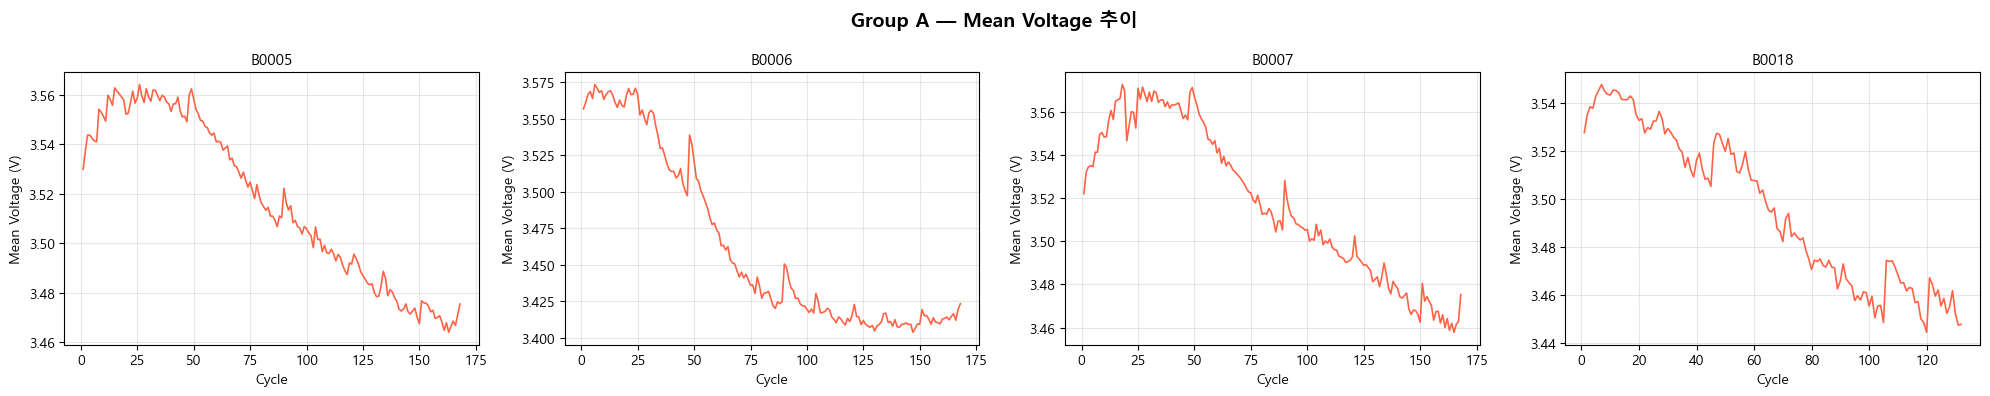

Group A 저장 완료


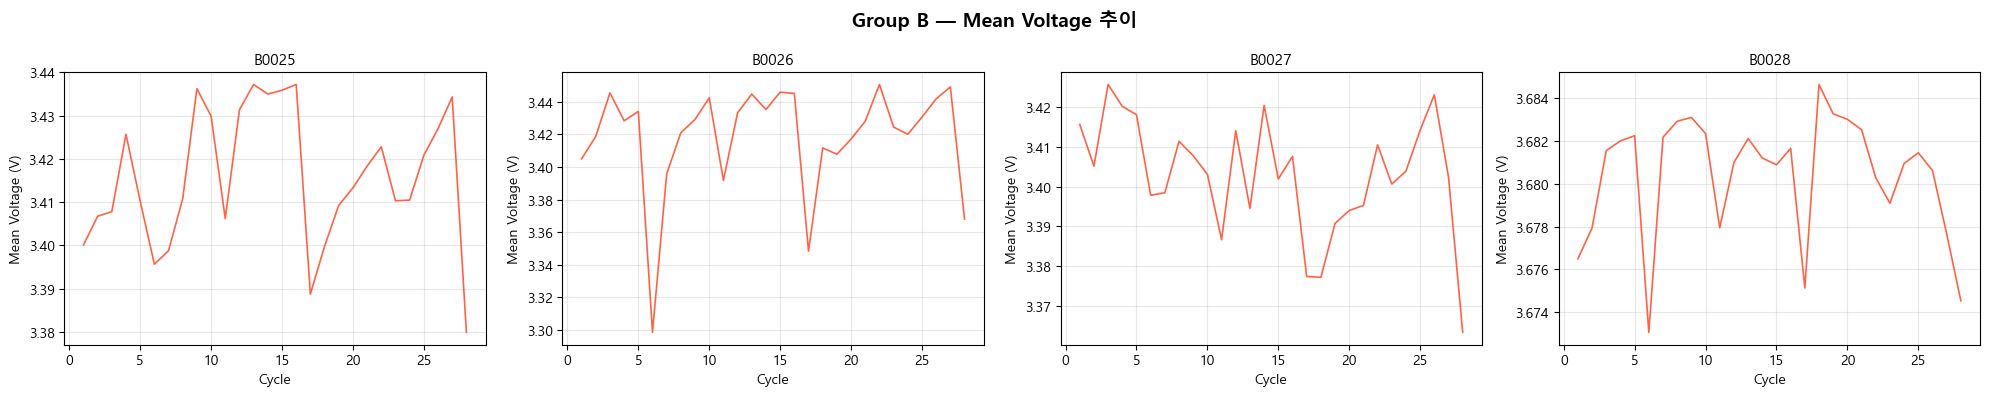

Group B 저장 완료


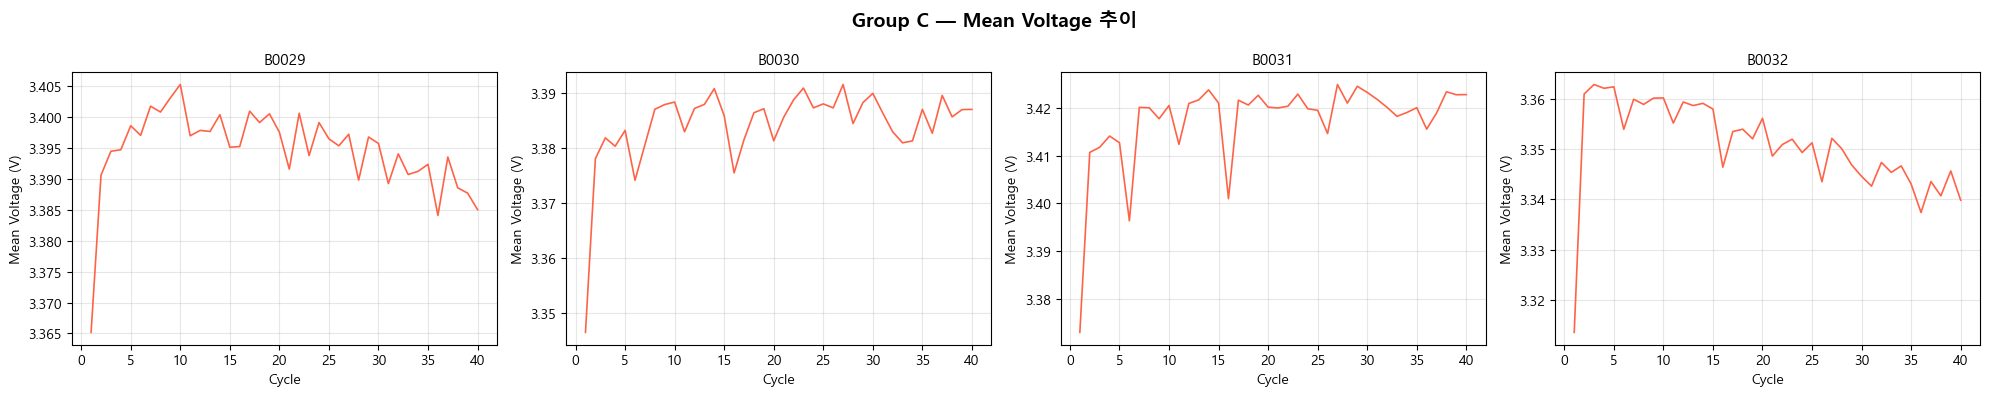

Group C 저장 완료


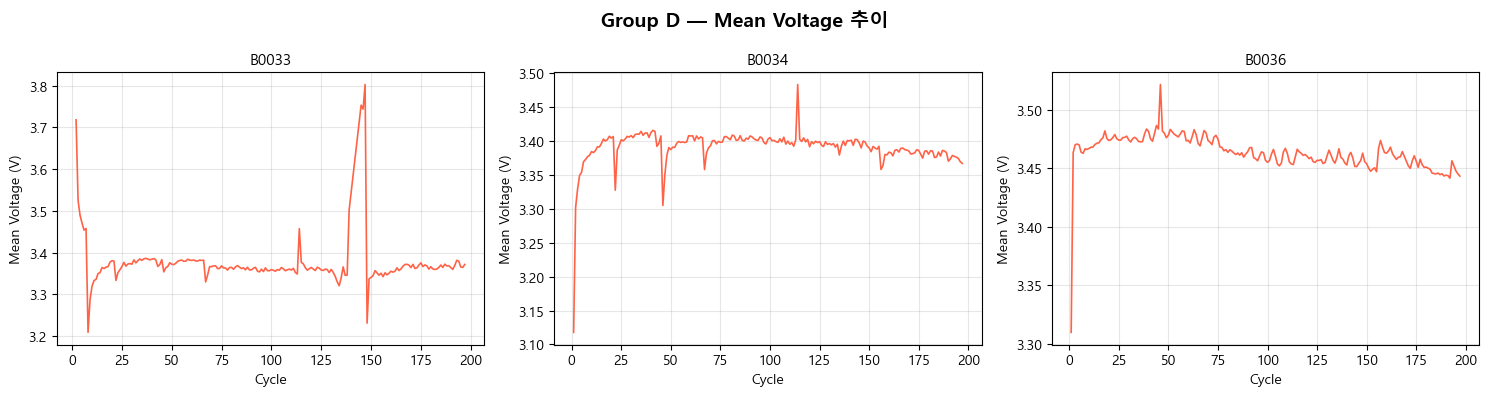

Group D 저장 완료


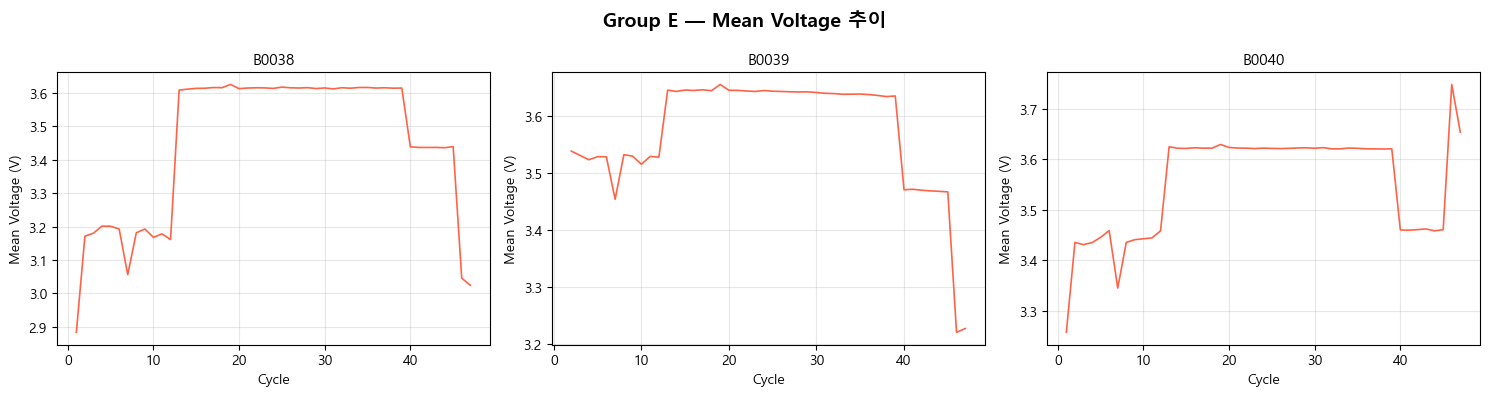

Group E 저장 완료


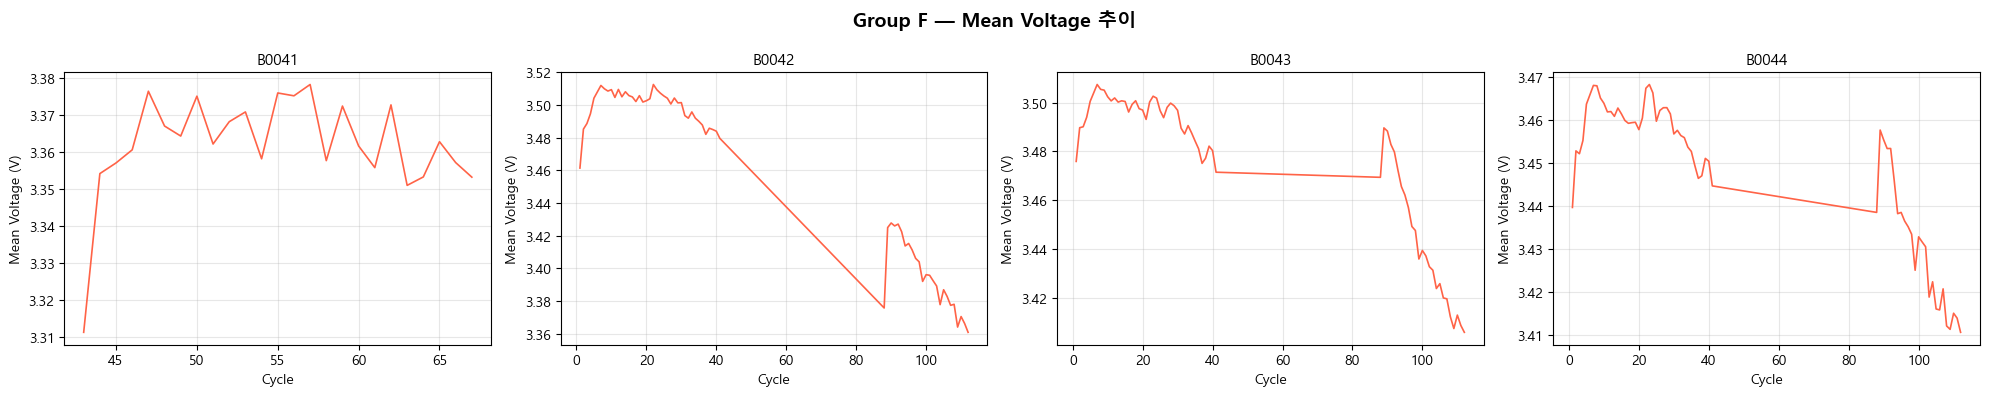

Group F 저장 완료


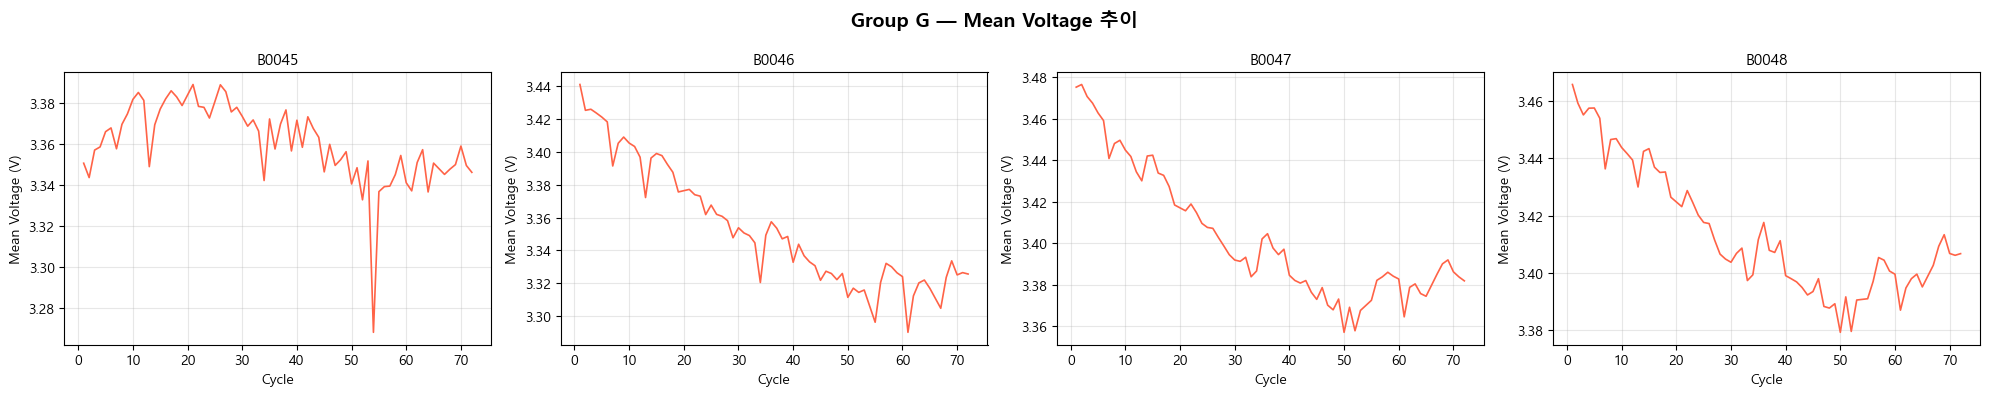

Group G 저장 완료


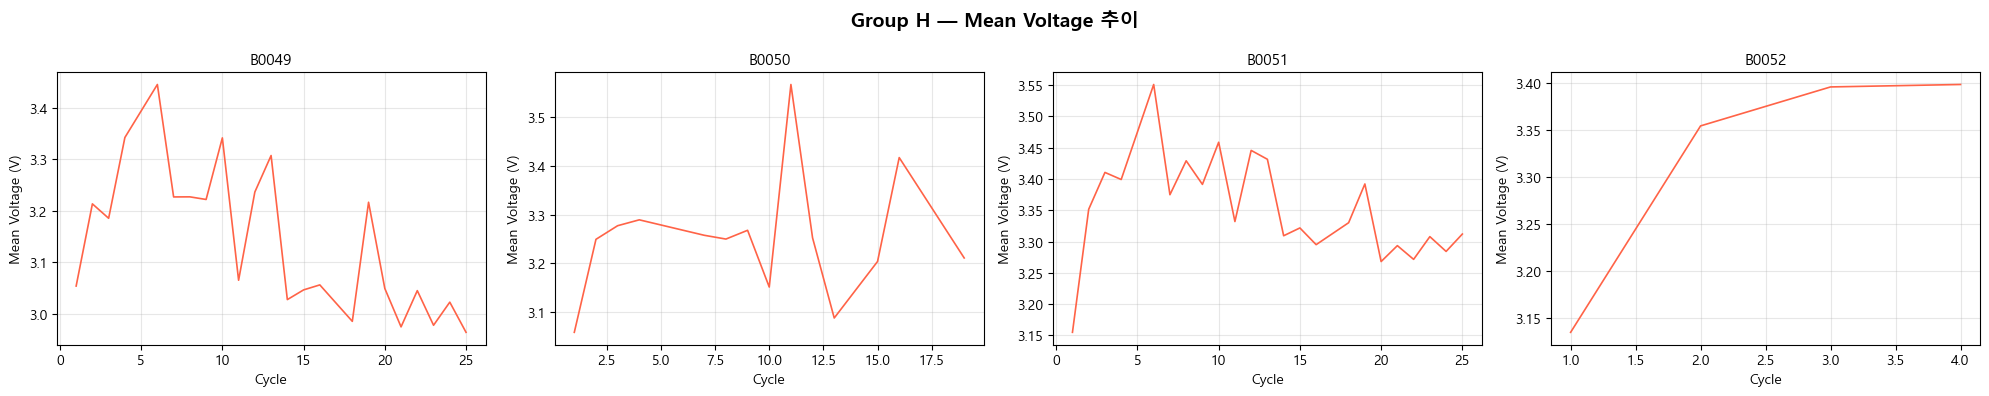

Group H 저장 완료


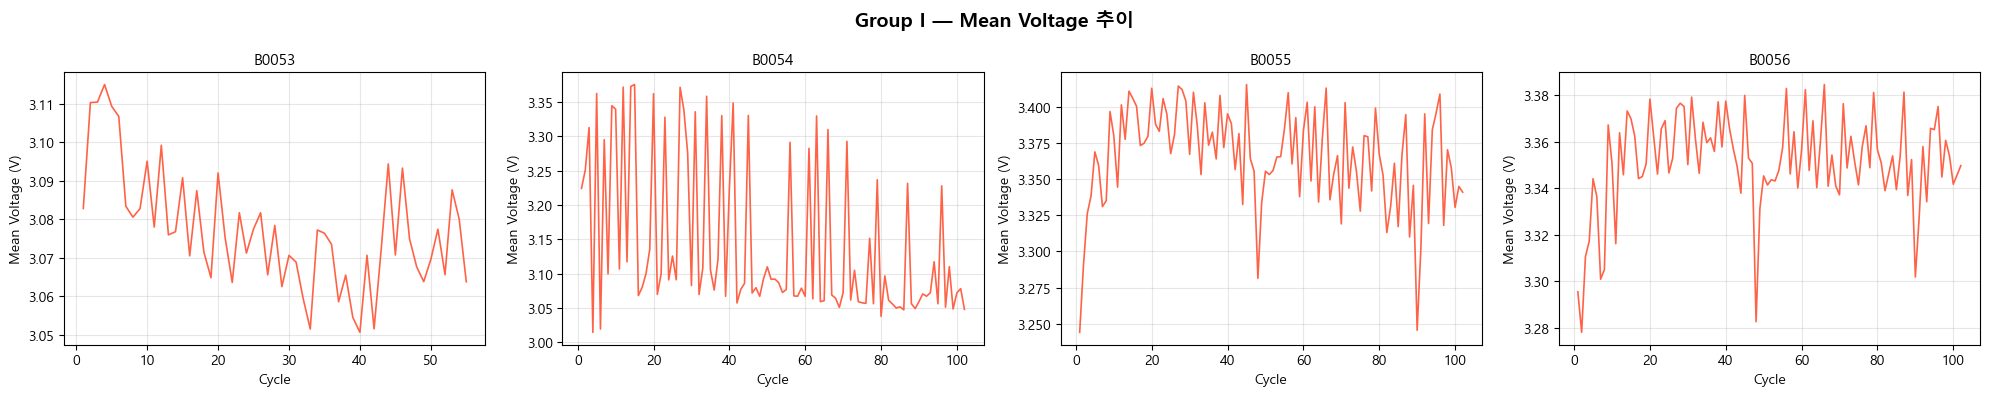

Group I 저장 완료


In [28]:
import matplotlib.pyplot as plt

# 1단계: uid당 평균 Voltage 집계
df_volt_agg = (
    df_exp_discharge
    .groupby(['battery_id', 'uid', 'group', 'SOH_nominal'])
    ['Voltage_measured']
    .mean()
    .reset_index()
    .rename(columns={'Voltage_measured': 'mean_voltage'})
)

# 2단계: discharge_cycle_raw 붙이기 (metadata에서)
df_cycle = df_discharge[['uid', 'discharge_cycle_raw']].drop_duplicates()
df_volt_agg = df_volt_agg.merge(df_cycle, on='uid', how='left')

# 3단계: 그룹별 배터리별 시각화
groups = sorted(df_volt_agg['group'].dropna().unique())

for grp in groups:
    df_grp = df_volt_agg[df_volt_agg['group'] == grp]
    batteries = sorted(df_grp['battery_id'].unique())
    n_bat = len(batteries)

    fig, axes = plt.subplots(1, n_bat, figsize=(5 * n_bat, 4))
    fig.suptitle(f'Group {grp} — Mean Voltage 추이', fontsize=14, fontweight='bold')

    # 배터리 1개일 경우 axes 형태 통일
    if n_bat == 1:
        axes = [axes]

    for j, bat in enumerate(batteries):
        df_bat = df_grp[df_grp['battery_id'] == bat].sort_values('discharge_cycle_raw')

        axes[j].plot(
            df_bat['discharge_cycle_raw'],
            df_bat['mean_voltage'],
            color='tomato',
            linewidth=1.2
        )
        axes[j].set_title(bat, fontsize=11)
        axes[j].set_xlabel('Cycle')
        axes[j].set_ylabel('Mean Voltage (V)')
        axes[j].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'eda_group_{grp}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Group {grp} 저장 완료")

In [29]:
import matplotlib.cm as cm
import numpy as np

# 먼저 이걸 실행하세요
df_agg = (
    df_exp_discharge
    .groupby(['battery_id', 'uid', 'group', 'Capacity', 'SOH_nominal'])
    [['Voltage_measured', 'Current_measured', 'Temperature_measured']]
    .mean()
    .reset_index()
    .rename(columns={
        'Voltage_measured':     'mean_voltage',
        'Current_measured':     'mean_current',
        'Temperature_measured': 'mean_temp'
    })
)

print(df_agg.shape)
df_agg.head()

(2553, 8)


,battery_id,uid,group,Capacity,SOH_nominal,mean_voltage,mean_current,mean_temp
0,B0005,5122,A,1.856487,92.82,3.529829,-1.818702,32.572328
1,B0005,5124,A,1.846327,92.32,3.537320,-1.817560,32.725235
2,B0005,5126,A,1.835349,91.77,3.543737,-1.816487,32.642862
3,B0005,5128,A,1.835263,91.76,3.543666,-1.825589,32.514876
4,B0005,5130,A,1.834646,91.73,3.542343,-1.826114,32.382349


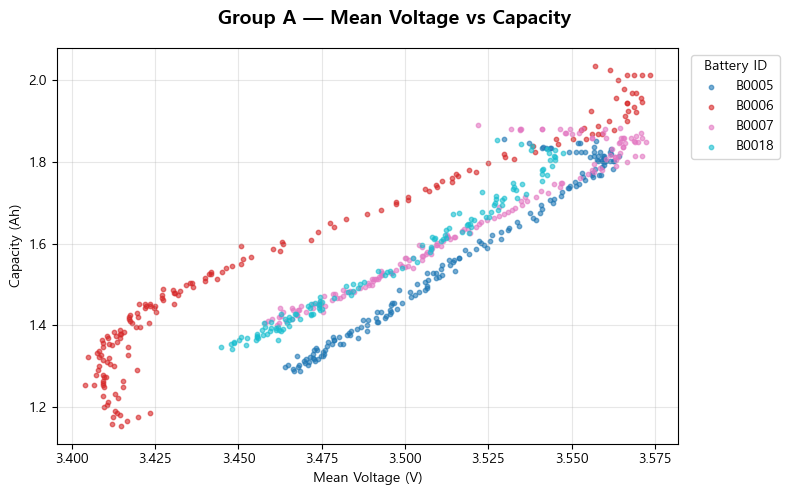

Group A 저장 완료


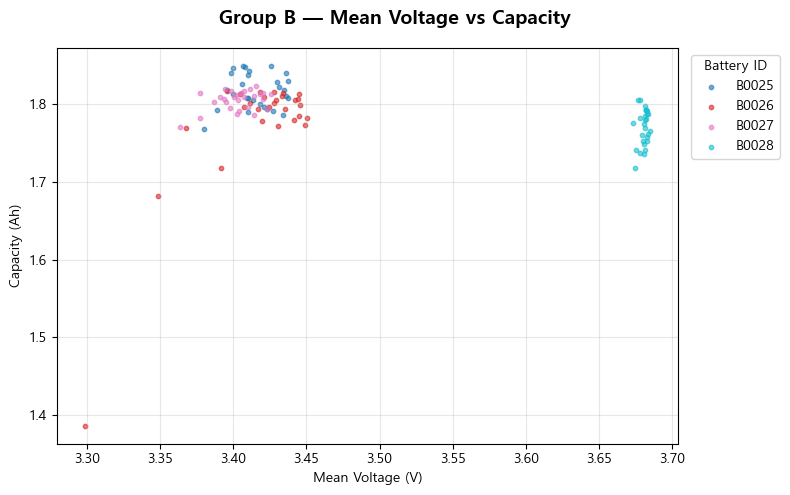

Group B 저장 완료


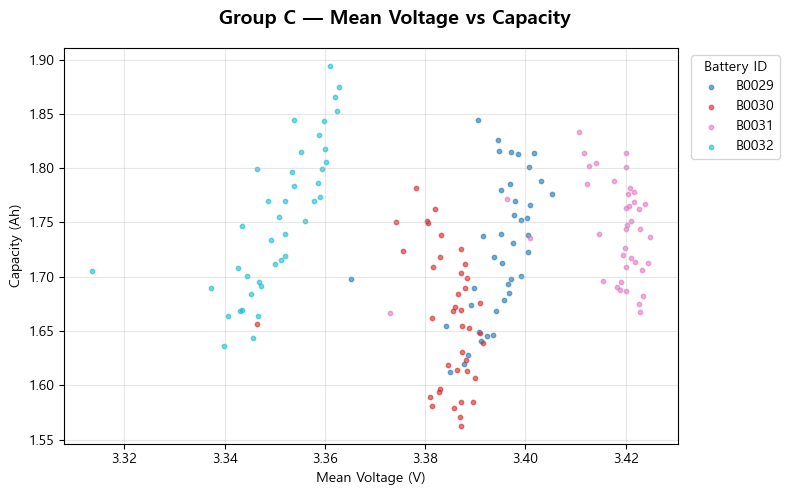

Group C 저장 완료


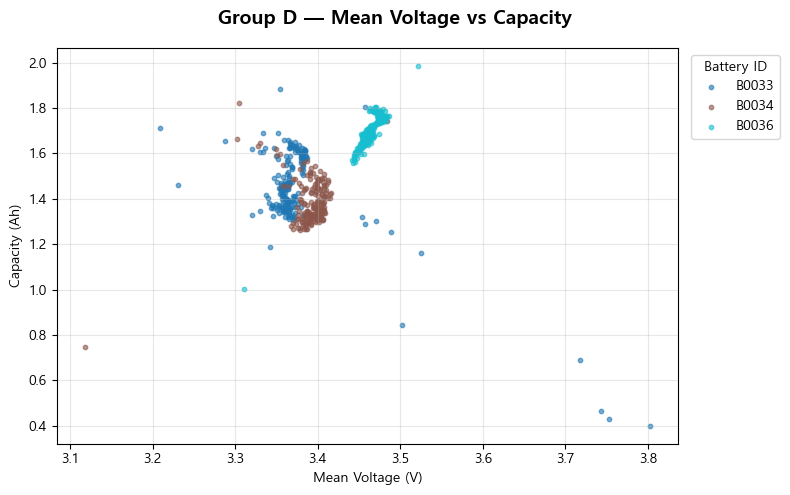

Group D 저장 완료


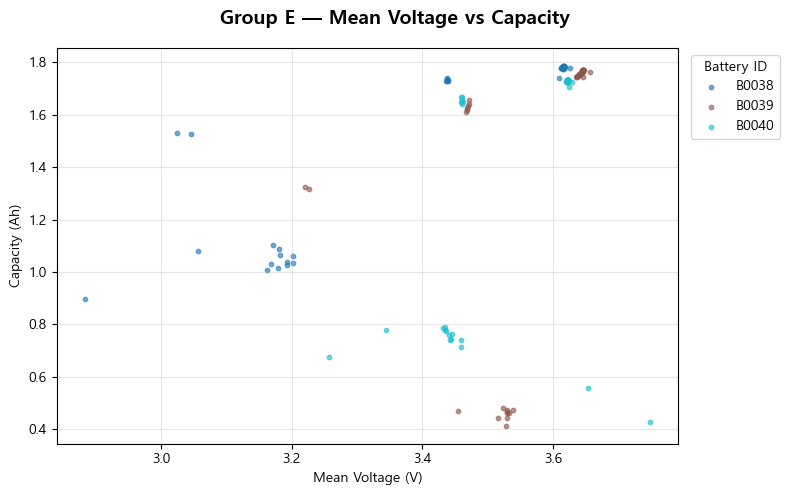

Group E 저장 완료


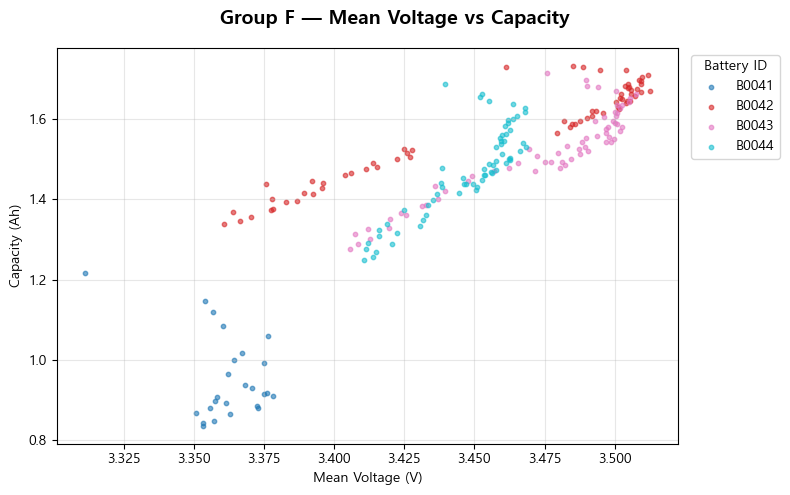

Group F 저장 완료


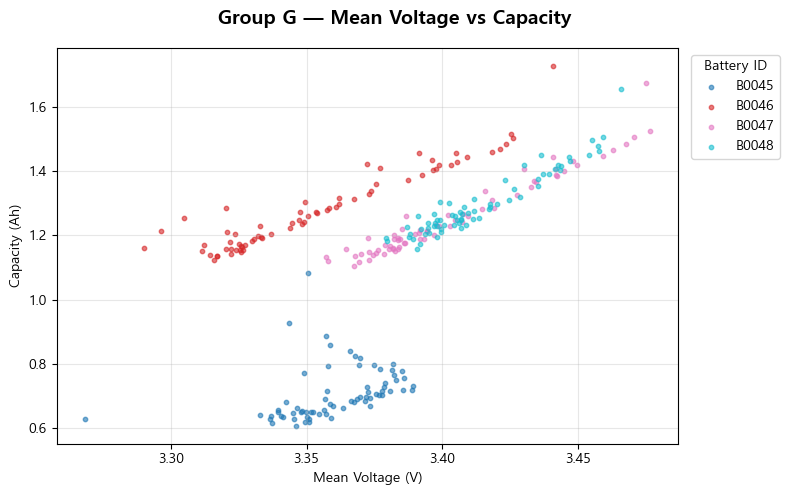

Group G 저장 완료


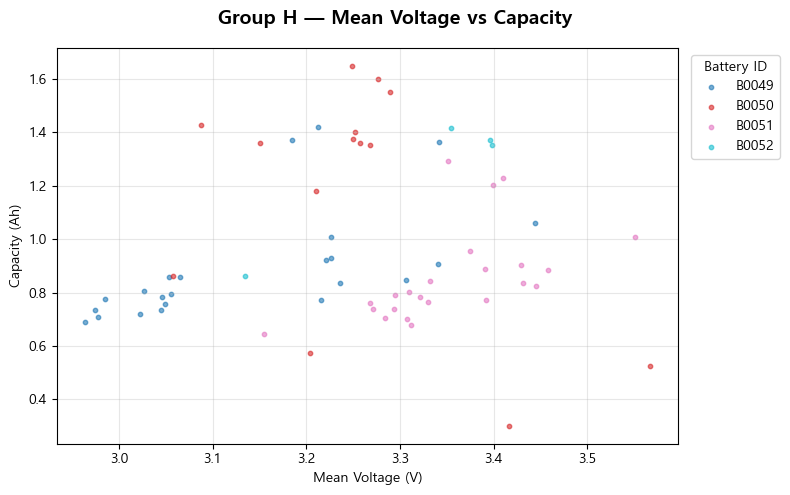

Group H 저장 완료


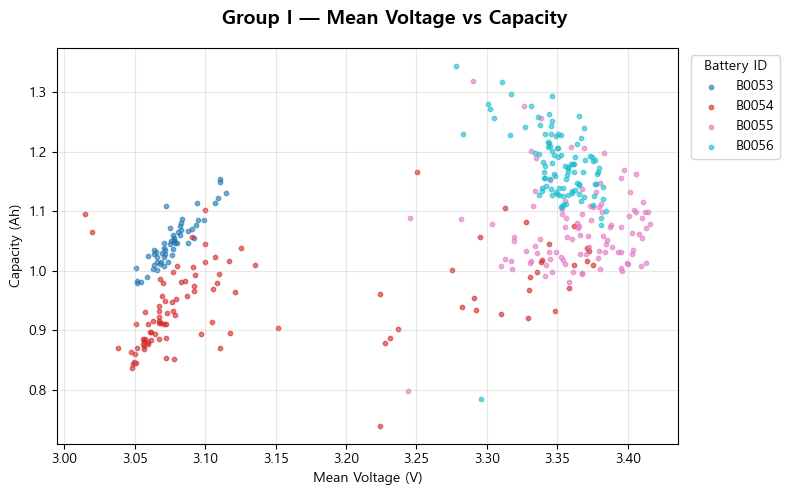

Group I 저장 완료


In [30]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

groups = sorted(df_agg['group'].dropna().unique())

for grp in groups:
    df_grp = df_agg[df_agg['group'] == grp]
    batteries = sorted(df_grp['battery_id'].unique())
    
    # 배터리 수만큼 색상 생성
    colors = cm.tab10(np.linspace(0, 1, len(batteries)))

    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f'Group {grp} — Mean Voltage vs Capacity', fontsize=14, fontweight='bold')

    for bat, color in zip(batteries, colors):
        df_bat = df_grp[df_grp['battery_id'] == bat]
        ax.scatter(
            df_bat['mean_voltage'],
            df_bat['Capacity'],
            s=10, alpha=0.6,
            color=color,
            label=bat
        )

    ax.set_xlabel('Mean Voltage (V)')
    ax.set_ylabel('Capacity (Ah)')
    ax.legend(title='Battery ID', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'eda_meanvolt_cap_group_{grp}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Group {grp} 저장 완료")

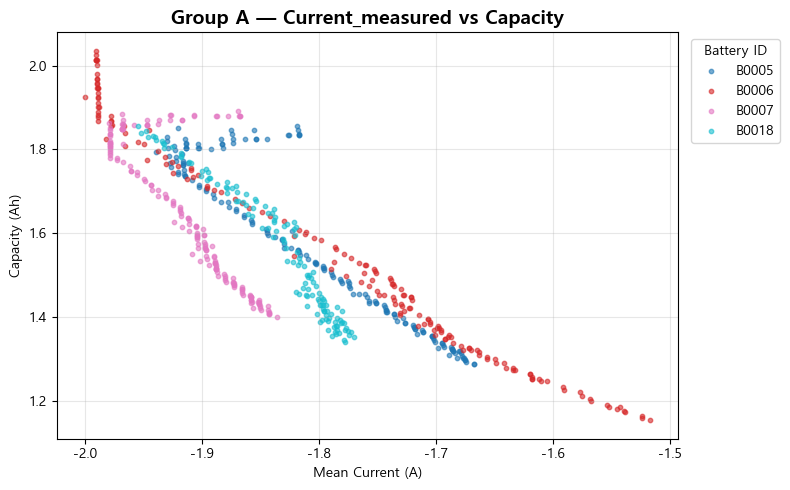

Group A 저장 완료


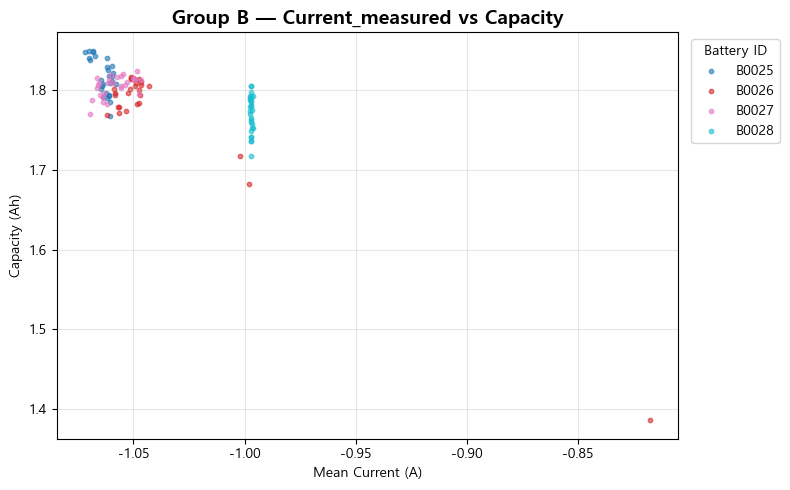

Group B 저장 완료


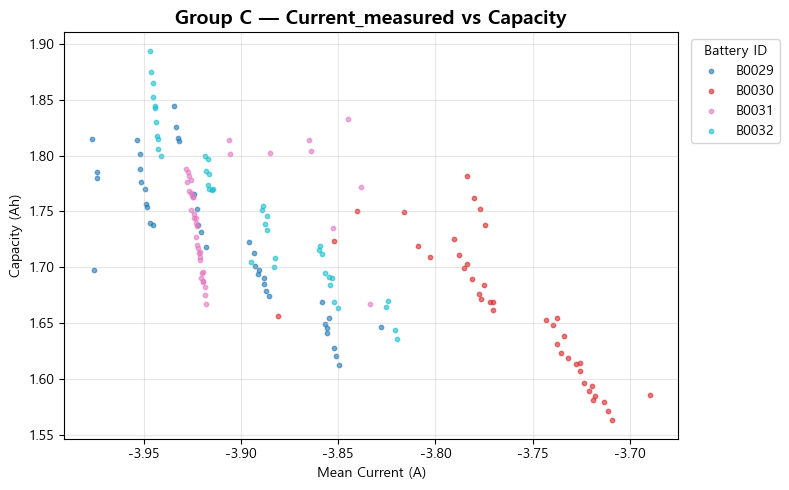

Group C 저장 완료


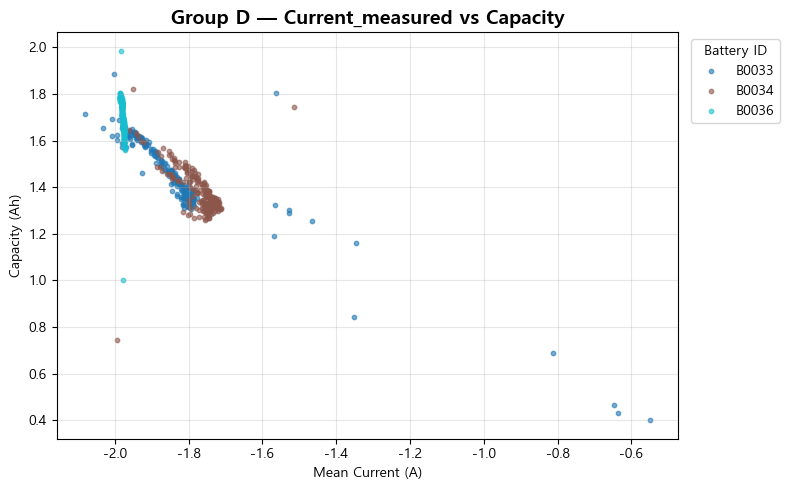

Group D 저장 완료


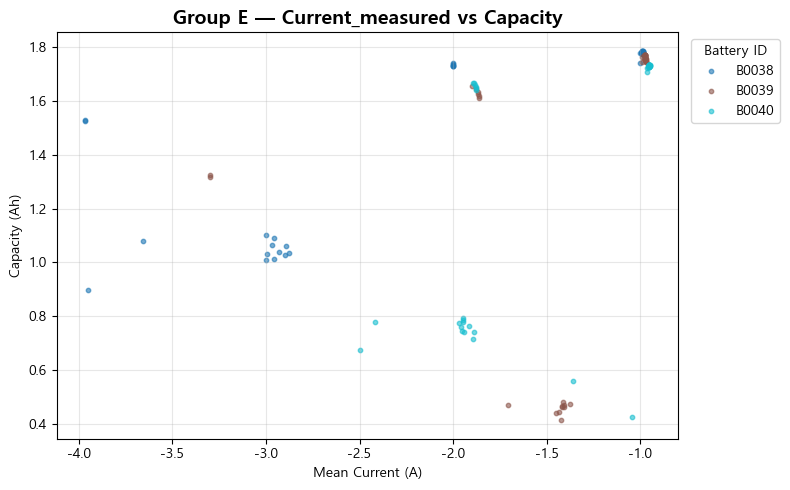

Group E 저장 완료


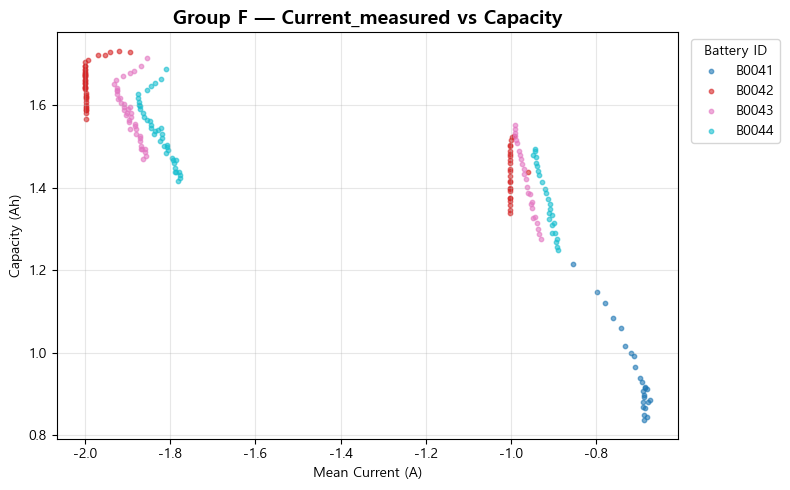

Group F 저장 완료


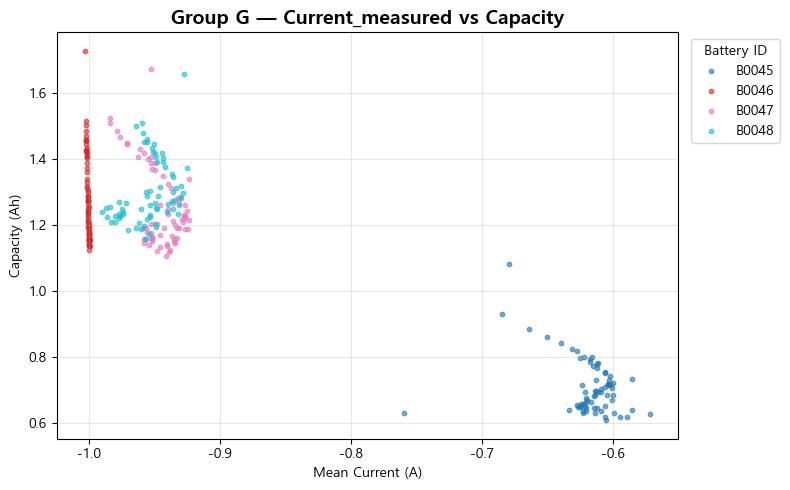

Group G 저장 완료


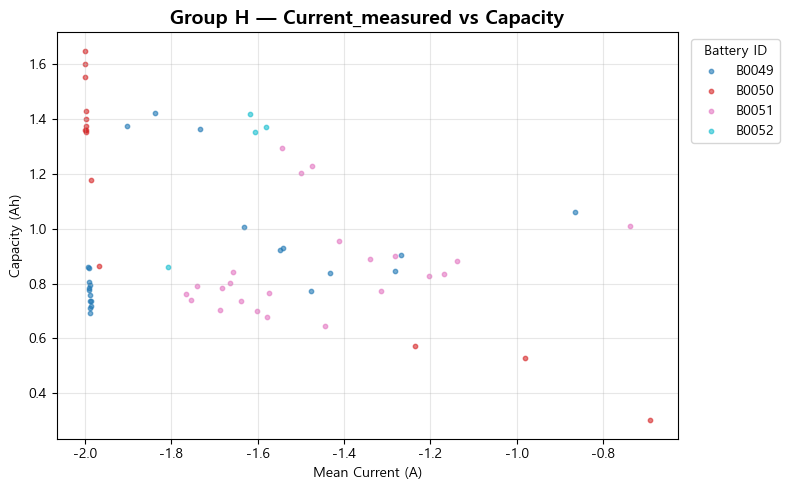

Group H 저장 완료


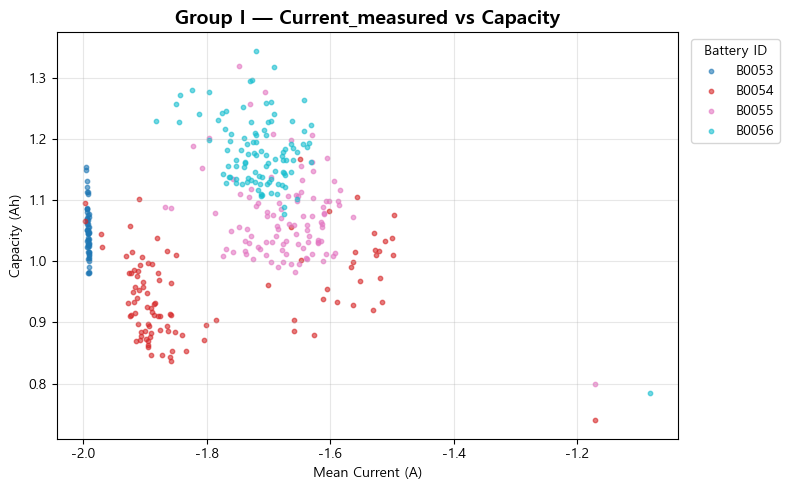

Group I 저장 완료


In [31]:
groups = sorted(df_agg['group'].dropna().unique())

for grp in groups:
    df_grp = df_agg[df_agg['group'] == grp]
    batteries = sorted(df_grp['battery_id'].unique())
    colors = cm.tab10(np.linspace(0, 1, len(batteries)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f'Group {grp} — Current_measured vs Capacity', fontsize=14, fontweight='bold')

    for bat, color in zip(batteries, colors):
        df_bat = df_grp[df_grp['battery_id'] == bat]
        ax.scatter(df_bat['mean_current'], df_bat['Capacity'],
                   s=10, alpha=0.6, color=color, label=bat)

    ax.set_xlabel('Mean Current (A)')
    ax.set_ylabel('Capacity (Ah)')
    ax.legend(title='Battery ID', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'eda_current_cap_group_{grp}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Group {grp} 저장 완료")

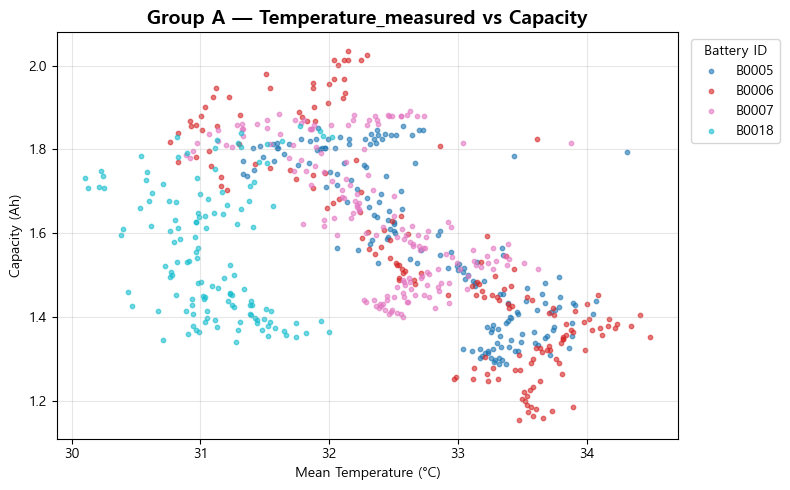

Group A 저장 완료


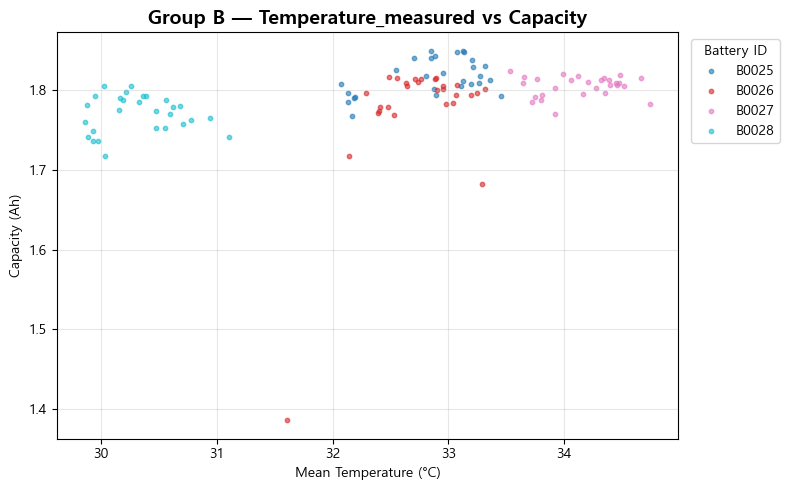

Group B 저장 완료


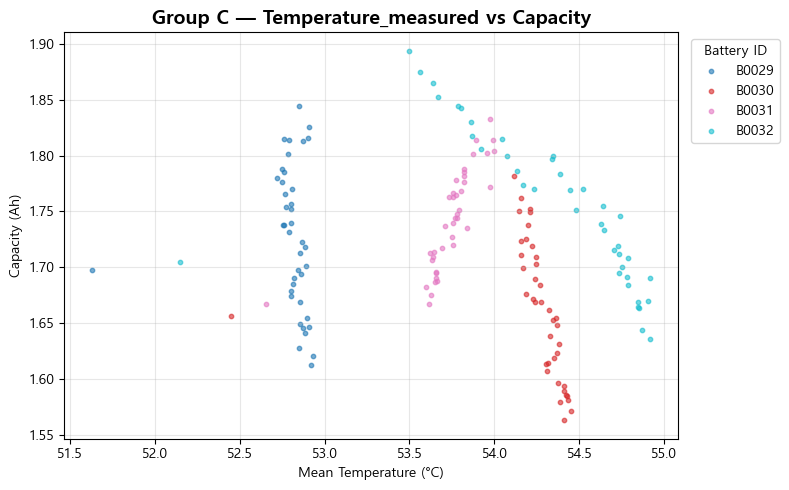

Group C 저장 완료


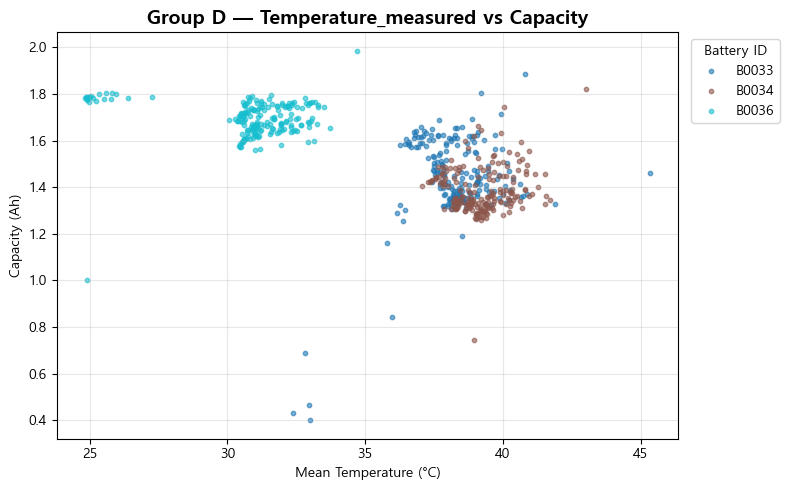

Group D 저장 완료


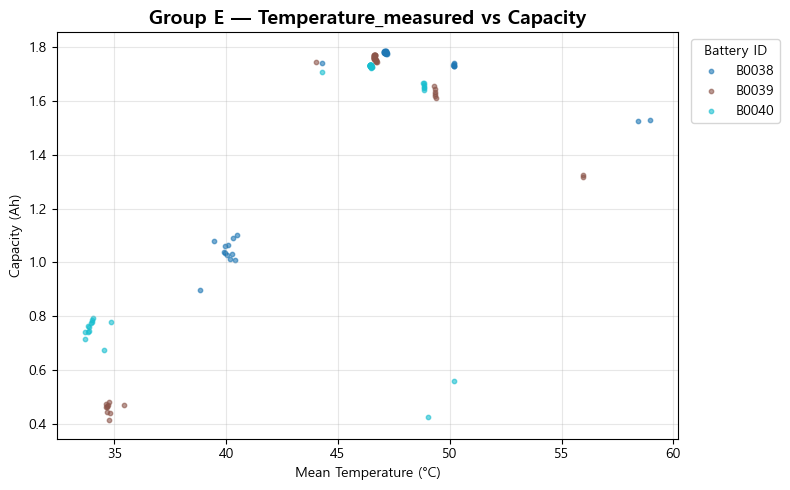

Group E 저장 완료


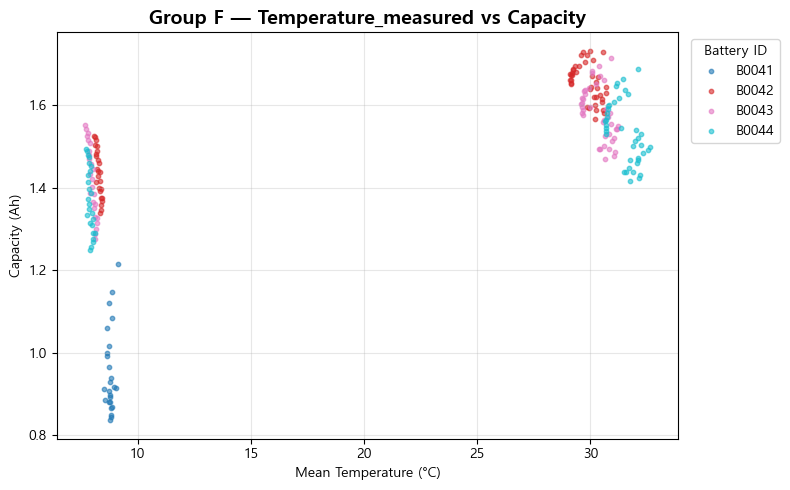

Group F 저장 완료


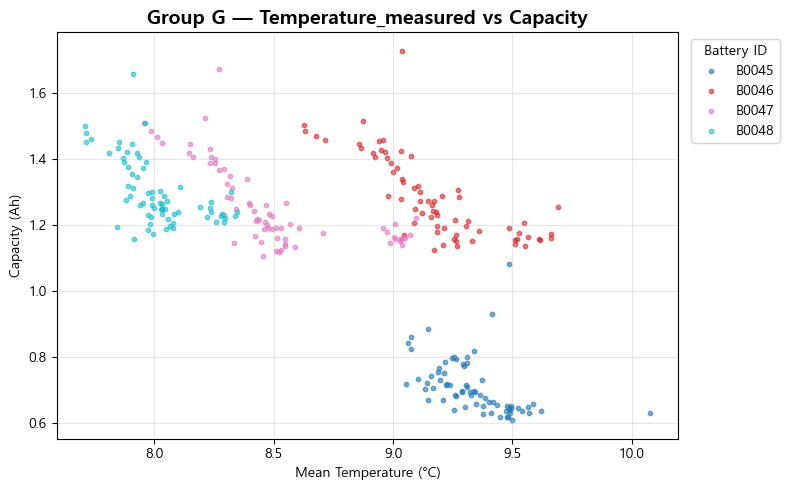

Group G 저장 완료


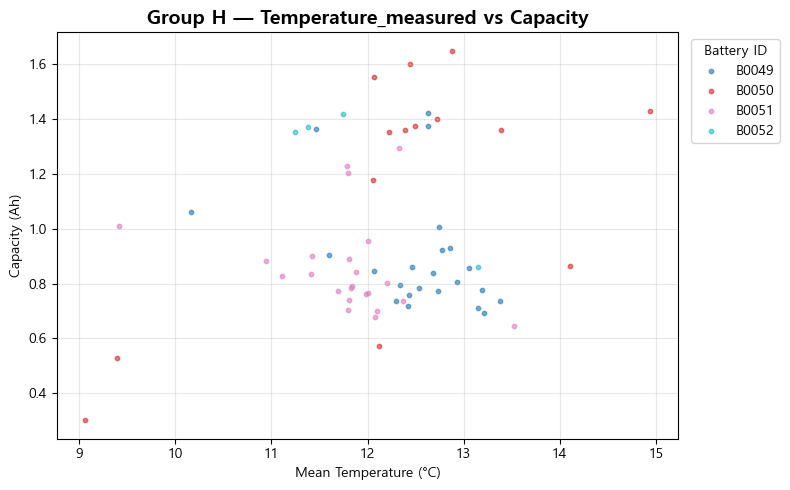

Group H 저장 완료


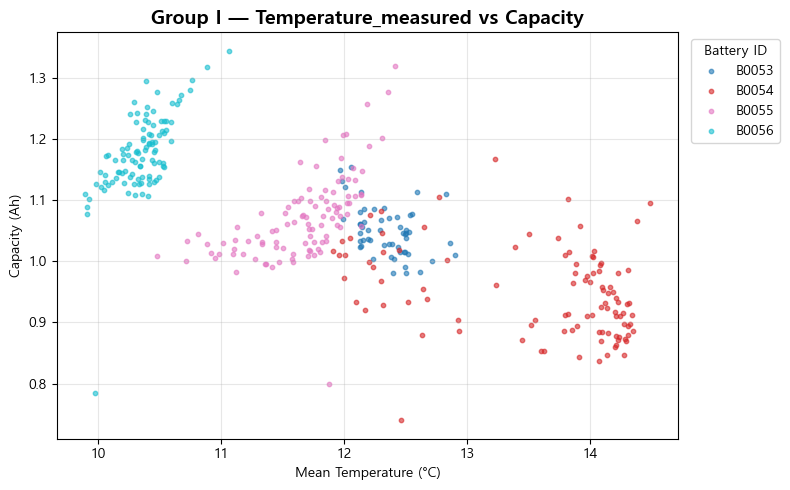

Group I 저장 완료


In [32]:
groups = sorted(df_agg['group'].dropna().unique())

for grp in groups:
    df_grp = df_agg[df_agg['group'] == grp]
    batteries = sorted(df_grp['battery_id'].unique())
    colors = cm.tab10(np.linspace(0, 1, len(batteries)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f'Group {grp} — Temperature_measured vs Capacity', fontsize=14, fontweight='bold')

    for bat, color in zip(batteries, colors):
        df_bat = df_grp[df_grp['battery_id'] == bat]
        ax.scatter(df_bat['mean_temp'], df_bat['Capacity'],
                   s=10, alpha=0.6, color=color, label=bat)

    ax.set_xlabel('Mean Temperature (°C)')
    ax.set_ylabel('Capacity (Ah)')
    ax.legend(title='Battery ID', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'eda_temp_cap_group_{grp}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Group {grp} 저장 완료")

In [33]:
# 순서 확인 (discharge_cycle_raw 제외)
df_seq = (
    df[df['battery_id'] == 'B0005'][['battery_id', 'type', 'start_time']]
    .sort_values('start_time')
    .head(30)
)
print(df_seq.to_string(index=False))

battery_id      type          start_time
     B0005    charge 2008-04-02 13:08:17
     B0005 discharge 2008-04-02 15:25:41
     B0005    charge 2008-04-02 16:37:51
     B0005 discharge 2008-04-02 19:43:48
     B0005    charge 2008-04-02 20:55:40
     B0005 discharge 2008-04-03 00:01:06
     B0005    charge 2008-04-03 01:12:38
     B0005 discharge 2008-04-03 04:16:37
     B0005    charge 2008-04-03 05:27:49
     B0005 discharge 2008-04-03 08:33:25
     B0005    charge 2008-04-03 09:44:35
     B0005 discharge 2008-04-03 12:55:10
     B0005    charge 2008-04-03 14:06:43
     B0005 discharge 2008-04-03 17:17:16
     B0005    charge 2008-04-03 18:28:47
     B0005 discharge 2008-04-03 21:28:14
     B0005    charge 2008-04-03 22:38:27
     B0005 discharge 2008-04-04 01:38:15
     B0005    charge 2008-04-04 02:48:06
     B0005 discharge 2008-04-04 05:48:08
     B0005    charge 2008-04-04 06:58:00
     B0005 discharge 2008-04-04 09:57:19
     B0005    charge 2008-04-04 11:06:50
     B0005    ch

In [34]:
# discharge vs impedance 횟수 비교
df_count = (
    df[df['type'].isin(['discharge', 'impedance'])]
    .groupby(['battery_id', 'type'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
print(df_count.to_string(index=False))

battery_id  discharge  impedance
     B0005        168        278
     B0006        168        278
     B0007        168        278
     B0018        132         53
     B0025         28         21
     B0026         28         21
     B0027         28         21
     B0028         28         21
     B0029         40         17
     B0030         40         17
     B0031         40         17
     B0032         40         17
     B0033        197         92
     B0034        197         92
     B0036        197         92
     B0038         47         28
     B0039         47         28
     B0040         47         28
     B0041         67         29
     B0042        112         50
     B0043        112         50
     B0044        112         50
     B0045         72         40
     B0046         72         40
     B0047         72         40
     B0048         72         40
     B0049         25         12
     B0050         25         12
     B0051         25         12
     B0052

In [35]:
import pandas as pd

# discharge, impedance 각각 시간 기준으로 준비
df_dis_time = df_discharge[['battery_id', 'group', 'discharge_cycle_raw', 
                             'Capacity', 'SOH_nominal', 'start_time']].copy()
df_imp_time = df_impedance[['battery_id', 'Rct', 'start_time']].dropna(subset=['Rct']).copy()

# battery_id별로 backward 매칭
records = []
for bat in df_dis_time['battery_id'].unique():
    dis = df_dis_time[df_dis_time['battery_id'] == bat].copy()
    imp = df_imp_time[df_imp_time['battery_id'] == bat].copy()
    
    if imp.empty:
        continue
    
    # 각 discharge 시점에서 가장 가까운 impedance의 Rct 붙이기
    imp_sorted = imp.sort_values('start_time')
    merged = pd.merge_asof(
        dis.sort_values('start_time'),
        imp_sorted[['start_time', 'Rct']],
        on='start_time',
        direction='backward'   # 가장 가까운 시점의 impedance 매칭
    )
    records.append(merged)

df_rct_cap = pd.concat(records, ignore_index=True)

# 매칭 결과 확인
print(df_rct_cap.shape)
print(df_rct_cap[df_rct_cap['battery_id'] == 'B0005'][
    ['battery_id', 'discharge_cycle_raw', 'Capacity', 'Rct', 'start_time']
].head(10).to_string(index=False))

(2794, 7)
battery_id  discharge_cycle_raw  Capacity  Rct          start_time
     B0005                    1  1.856487  NaN 2008-04-02 15:25:41
     B0005                    2  1.846327  NaN 2008-04-02 19:43:48
     B0005                    3  1.835349  NaN 2008-04-03 00:01:06
     B0005                    4  1.835263  NaN 2008-04-03 04:16:37
     B0005                    5  1.834646  NaN 2008-04-03 08:33:25
     B0005                    6  1.835662  NaN 2008-04-03 12:55:10
     B0005                    7  1.835146  NaN 2008-04-03 17:17:16
     B0005                    8  1.825757  NaN 2008-04-03 21:28:14
     B0005                    9  1.824774  NaN 2008-04-04 01:38:15
     B0005                   10  1.824613  NaN 2008-04-04 05:48:08


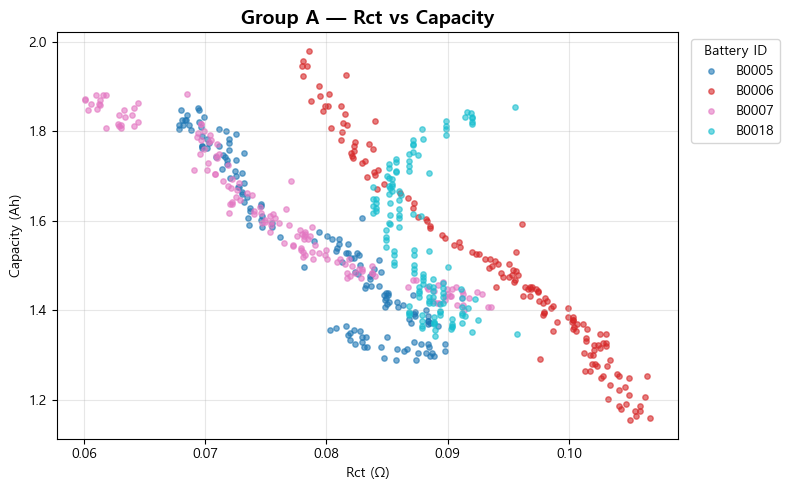

Group A 저장 완료


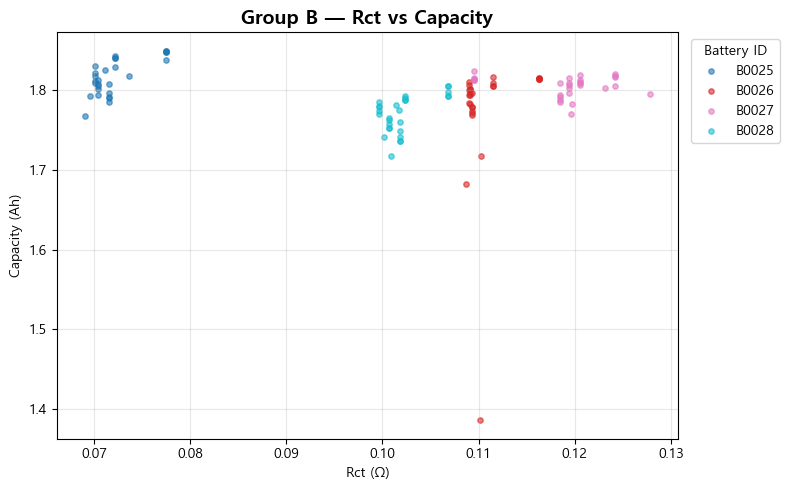

Group B 저장 완료


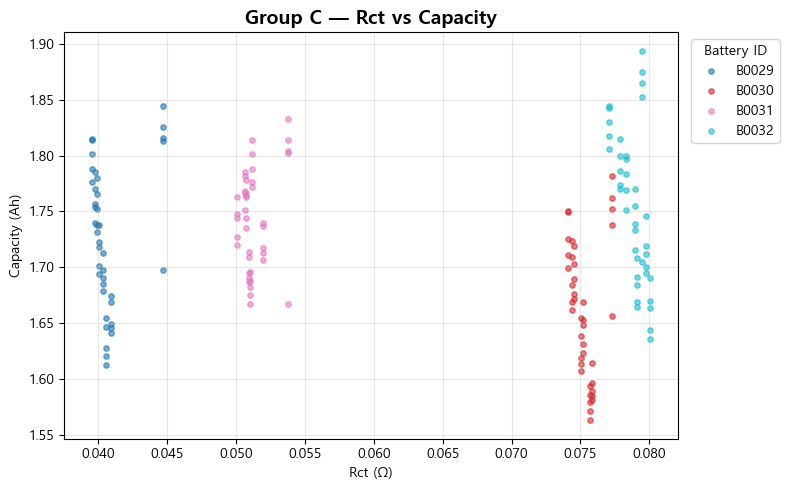

Group C 저장 완료


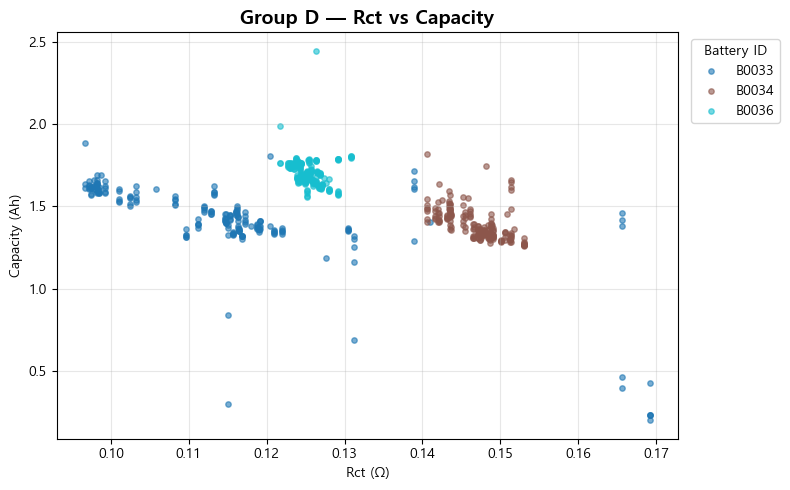

Group D 저장 완료


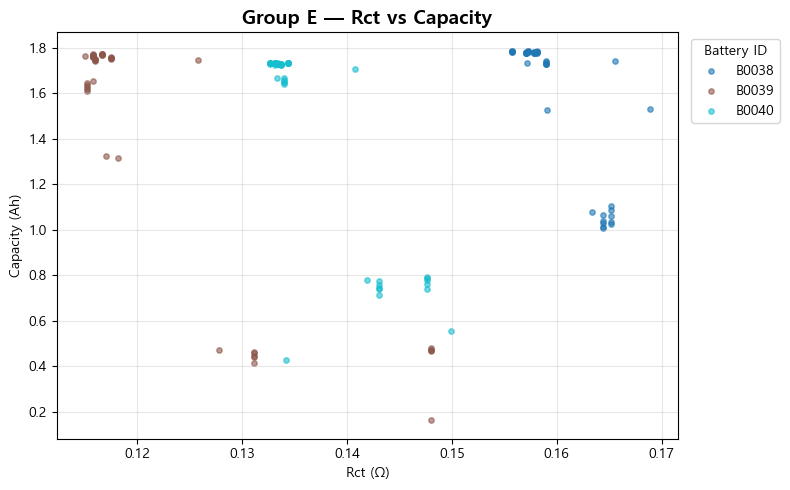

Group E 저장 완료


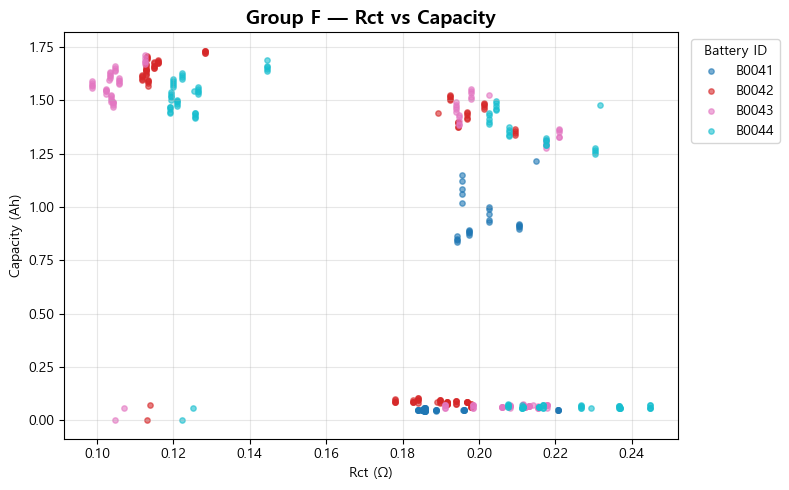

Group F 저장 완료


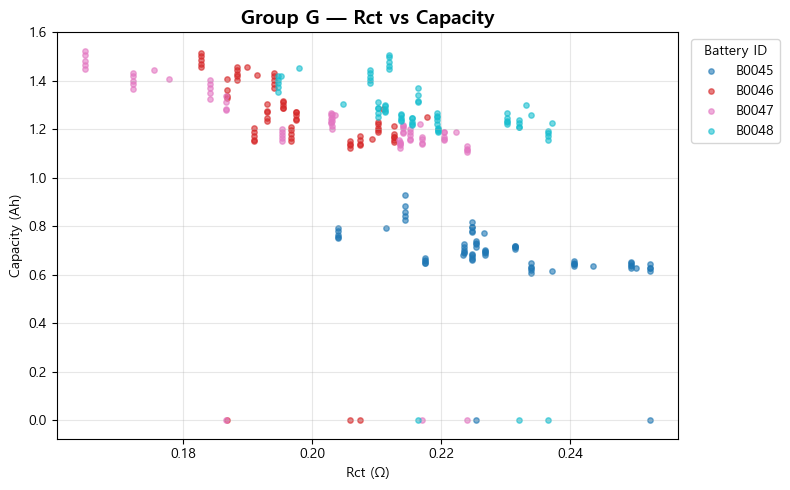

Group G 저장 완료


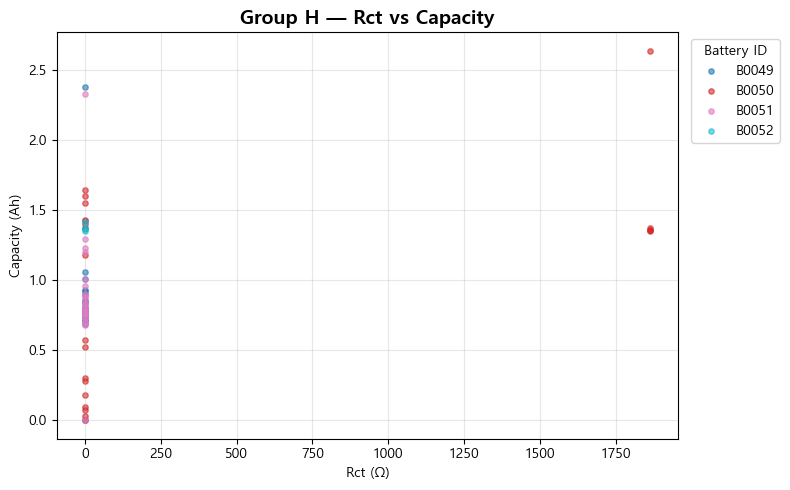

Group H 저장 완료


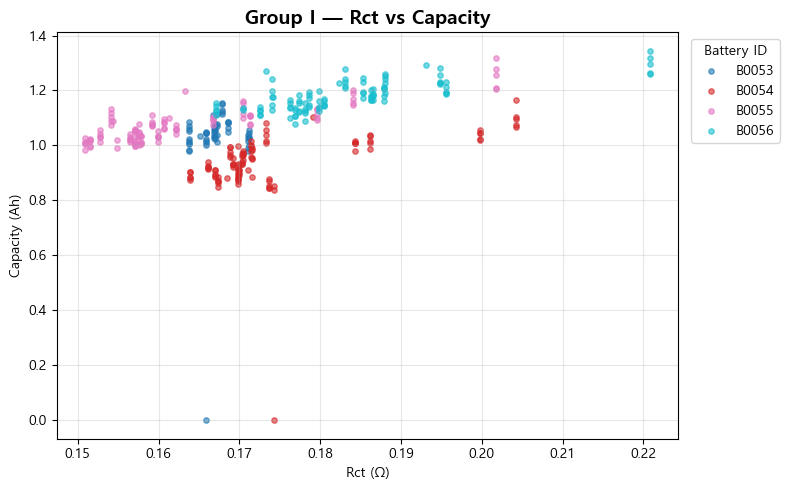

Group I 저장 완료


In [36]:
groups = sorted(df_rct_cap['group'].dropna().unique())

for grp in groups:
    df_grp = df_rct_cap[df_rct_cap['group'] == grp].dropna(subset=['Rct', 'Capacity'])
    batteries = sorted(df_grp['battery_id'].unique())
    colors = cm.tab10(np.linspace(0, 1, len(batteries)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f'Group {grp} — Rct vs Capacity', fontsize=14, fontweight='bold')

    for bat, color in zip(batteries, colors):
        df_bat = df_grp[df_grp['battery_id'] == bat].sort_values('discharge_cycle_raw')
        ax.scatter(df_bat['Rct'], df_bat['Capacity'],
                   s=15, alpha=0.6, color=color, label=bat)

    ax.set_xlabel('Rct (Ω)')
    ax.set_ylabel('Capacity (Ah)')
    ax.legend(title='Battery ID', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'eda_rct_cap_group_{grp}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Group {grp} 저장 완료")

In [37]:
# groups = sorted(df_rct_cap['group'].dropna().unique())

# for grp in groups:
#     df_grp = df_rct_cap[df_rct_cap['group'] == grp].dropna(subset=['Rct', 'SOH_nominal'])
#     batteries = sorted(df_grp['battery_id'].unique())

#     fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#     fig.suptitle(f'Group {grp} — SOH & Rct 분포', fontsize=14, fontweight='bold')

#     # SOH 박스플랏
#     data_soh = [df_grp[df_grp['battery_id'] == bat]['SOH_nominal'].values for bat in batteries]
#     bp1 = axes[0].boxplot(data_soh, labels=batteries, patch_artist=True)
#     colors = cm.tab10(np.linspace(0, 1, len(batteries)))
#     for patch, color in zip(bp1['boxes'], colors):
#         patch.set_facecolor(color)
#         patch.set_alpha(0.6)
#     axes[0].set_title('SOH 분포')
#     axes[0].set_xlabel('Battery ID')
#     axes[0].set_ylabel('SOH (%)')
#     axes[0].grid(True, alpha=0.3)

#     # Rct 박스플랏
#     data_rct = [df_grp[df_grp['battery_id'] == bat]['Rct'].values for bat in batteries]
#     bp2 = axes[1].boxplot(data_rct, labels=batteries, patch_artist=True)
#     for patch, color in zip(bp2['boxes'], colors):
#         patch.set_facecolor(color)
#         patch.set_alpha(0.6)
#     axes[1].set_title('Rct 분포')
#     axes[1].set_xlabel('Battery ID')
#     axes[1].set_ylabel('Rct (Ω)')
#     axes[1].grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.savefig(f'eda_boxplot_soh_rct_group_{grp}.png', dpi=150, bbox_inches='tight')
#     plt.show()
#     print(f"Group {grp} 저장 완료")

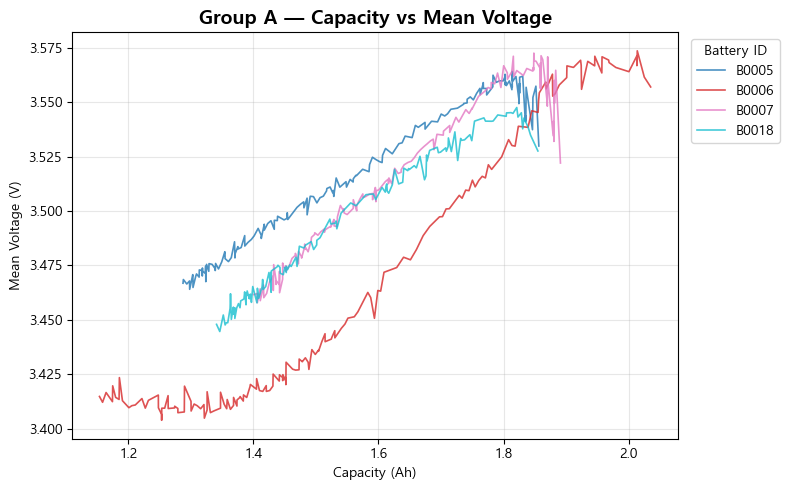

Group A 저장 완료


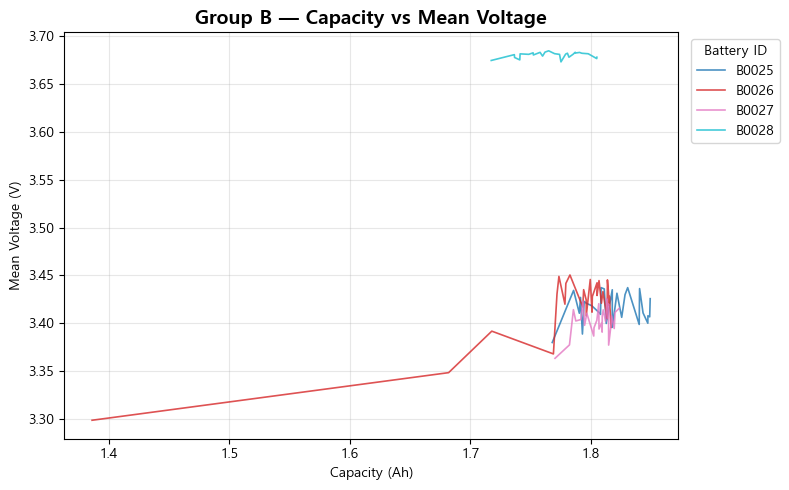

Group B 저장 완료


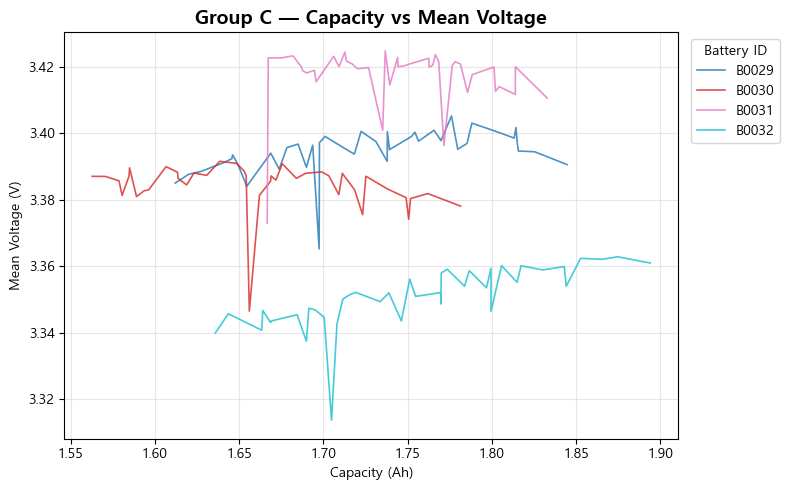

Group C 저장 완료


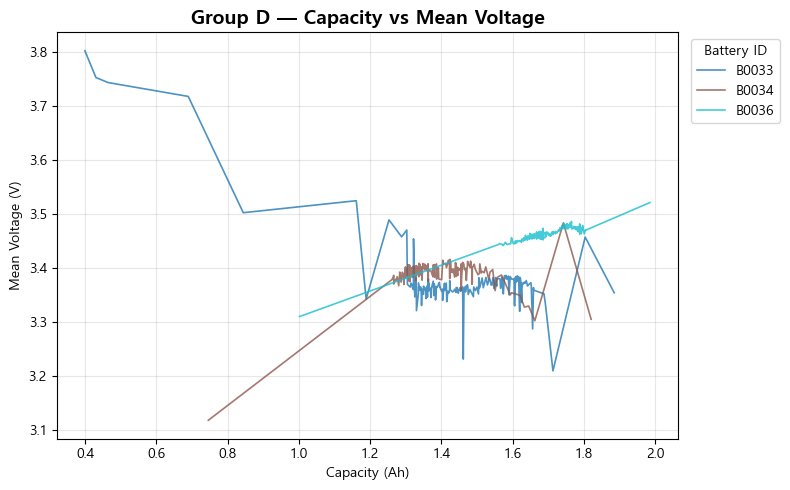

Group D 저장 완료


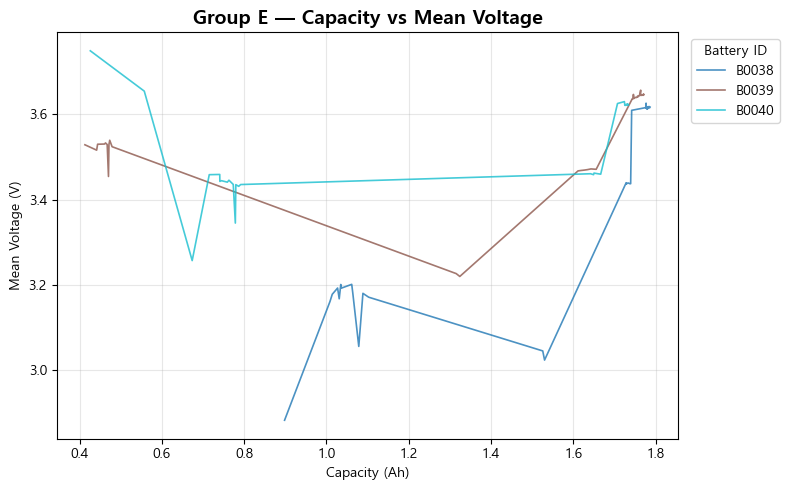

Group E 저장 완료


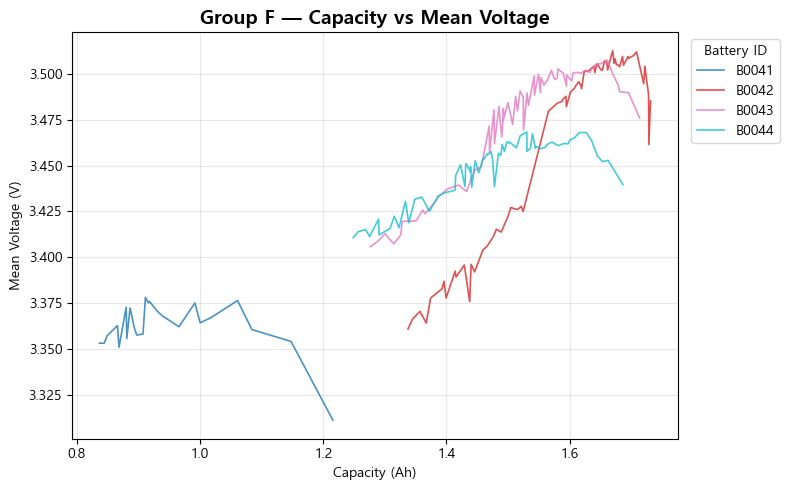

Group F 저장 완료


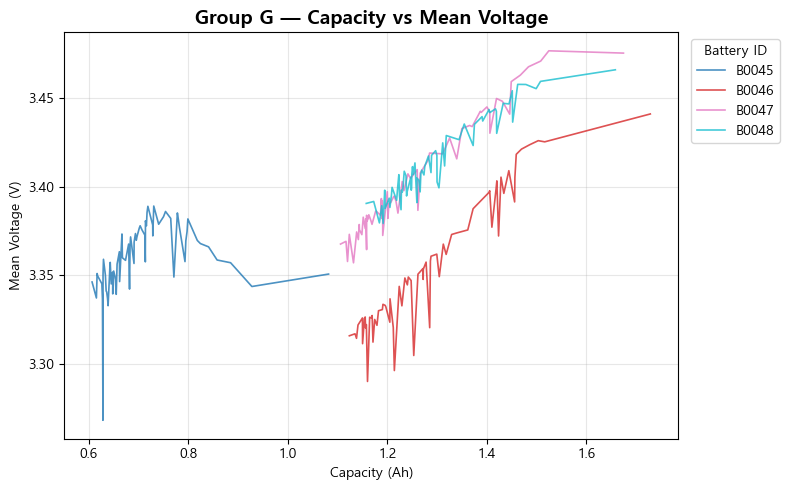

Group G 저장 완료


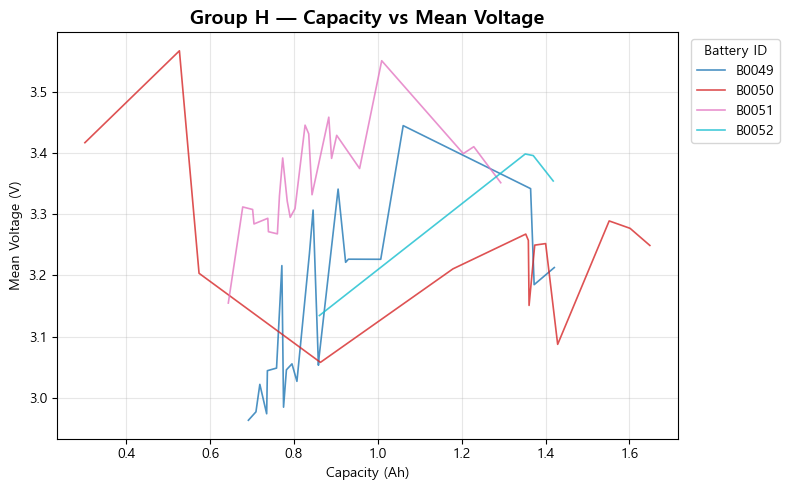

Group H 저장 완료


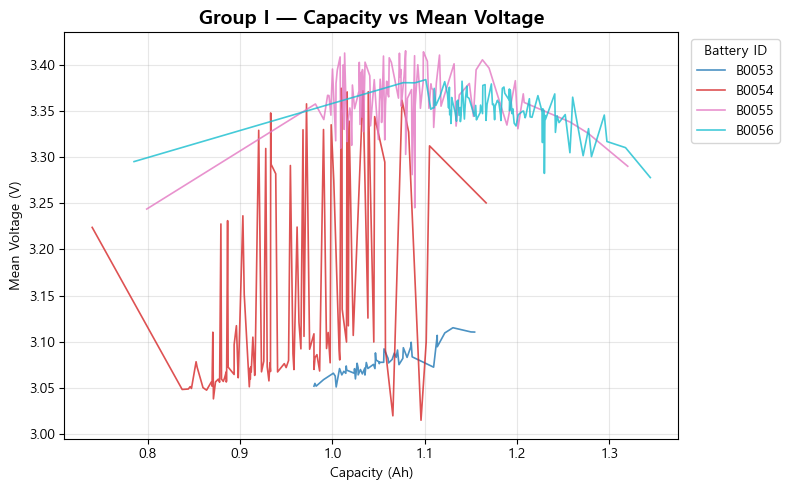

Group I 저장 완료


In [38]:
# uid별 평균 전압 + Capacity 집계 (df_agg 없이 df_exp_discharge에서 바로)
df_line = (
    df_exp_discharge
    .groupby(['battery_id', 'uid', 'group', 'Capacity', 'SOH_nominal'])
    ['Voltage_measured']
    .mean()
    .reset_index()
    .rename(columns={'Voltage_measured': 'mean_voltage'})
)

# 시각화
groups = sorted(df_line['group'].dropna().unique())

for grp in groups:
    df_grp = df_line[df_line['group'] == grp]
    batteries = sorted(df_grp['battery_id'].unique())
    colors = cm.tab10(np.linspace(0, 1, len(batteries)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.set_title(f'Group {grp} — Capacity vs Mean Voltage', fontsize=14, fontweight='bold')

    for bat, color in zip(batteries, colors):
        df_bat = df_grp[df_grp['battery_id'] == bat].sort_values('Capacity')  # Capacity 기준 정렬
        ax.plot(df_bat['Capacity'], df_bat['mean_voltage'],
                linewidth=1.2, alpha=0.8, color=color, label=bat)

    ax.set_xlabel('Capacity (Ah)')
    ax.set_ylabel('Mean Voltage (V)')
    ax.legend(title='Battery ID', bbox_to_anchor=(1.01, 1), loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'eda_line_volt_cap_group_{grp}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Group {grp} 저장 완료")

In [39]:
# ========================================
# 1단계: uid별 평균값 집계 (df_exp_discharge에서)
# ========================================
df_agg = (
    df_exp_discharge
    .groupby(['battery_id', 'uid', 'group', 'Capacity', 'SOH_nominal'])
    [['Voltage_measured', 'Current_measured', 'Temperature_measured']]
    .mean()
    .reset_index()
    .rename(columns={
        'Voltage_measured':     'mean_voltage',
        'Current_measured':     'mean_current',
        'Temperature_measured': 'mean_temp'
    })
)
# 결과: 1행 = uid 1개 (실험 1회)의 평균값

# ========================================
# 2단계: df_discharge에서 사이클 관련 컬럼 가져오기
# ========================================
df_cycle_info = df_discharge[[
    'uid', 'battery_id', 'group', 'discharge_cycle_raw',
    'Capacity', 'SOH_nominal', 'SOH_relative',
    'eol_cycle', 'RUL', 'analysis_role', 'end_reason',
    'ambient_temperature', 'start_time'
]].copy()
# 결과: 1행 = uid 1개의 메타 정보

# ========================================
# 3단계: 평균값 + 사이클 정보 합치기 (uid 기준)
# ========================================
df_summary = df_cycle_info.merge(
    df_agg[['uid', 'mean_voltage', 'mean_current', 'mean_temp']],
    on='uid',
    how='left'
)
# 결과: 1행 = 1 discharge cycle의 모든 정보

# ========================================
# 4단계: Rct를 시간 기준으로 붙이기 (merge_asof)
# ========================================
df_imp_time = df_impedance[['battery_id', 'Rct', 'start_time']].dropna(subset=['Rct']).copy()

records = []
for bat in df_summary['battery_id'].unique():
    dis = df_summary[df_summary['battery_id'] == bat].copy()
    imp = df_imp_time[df_imp_time['battery_id'] == bat].copy()
    if imp.empty:
        continue
    merged = pd.merge_asof(
        dis.sort_values('start_time'),
        imp.sort_values('start_time')[['start_time', 'Rct']],
        on='start_time',
        direction='nearest'
    )
    records.append(merged)

df_master = pd.concat(records, ignore_index=True)
# 결과: 1행 = 1 discharge cycle + Rct까지 포함된 최종 master 테이블

# ========================================
# 5단계: CSV 저장
# ========================================
save_path = r"C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\tableau_master.csv"
df_master.to_csv(save_path, index=False, encoding='utf-8-sig')

print("저장 완료!")
print("shape:", df_master.shape)
print("컬럼:", df_master.columns.tolist())

저장 완료!
shape: (2794, 17)
컬럼: ['uid', 'battery_id', 'group', 'discharge_cycle_raw', 'Capacity', 'SOH_nominal', 'SOH_relative', 'eol_cycle', 'RUL', 'analysis_role', 'end_reason', 'ambient_temperature', 'start_time', 'mean_voltage', 'mean_current', 'mean_temp', 'Rct']


In [40]:
print(df_master['Rct'].describe())
print(df_master['Rct'].sort_values(ascending=False).head(10))

count    2.794000e+03
mean     7.358065e+11
std      3.889348e+13
min     -2.091081e+02
25%      9.139165e-02
50%      1.286769e-01
75%      1.767775e-01
max      2.055843e+15
Name: Rct, dtype: float64
2360    2.055843e+15
2413    7.257334e+04
2414    7.257334e+04
2415    7.257334e+04
2411    5.835858e+04
2412    5.835858e+04
2428    3.935851e+04
2427    3.935851e+04
2426    3.935851e+04
2419    1.912866e+04
Name: Rct, dtype: float64


In [41]:
# Rct 이상값 제거 (정상 범위 0~1 사이만)
print("필터링 전:", df_master.shape)

df_master_clean = df_master[
    (df_master['Rct'].isna()) |  # null은 유지 (discharge 행)
    (df_master['Rct'].between(0, 1))  # Rct 있는 행은 0~1 사이만
].copy()

print("필터링 후:", df_master_clean.shape)
print(df_master_clean['Rct'].describe())

# CSV 다시 저장
save_path = r"C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\tableau_master.csv"
df_master_clean.to_csv(save_path, index=False, encoding='utf-8-sig')
print("저장 완료!")

필터링 전: (2794, 17)
필터링 후: (2768, 17)
count    2768.000000
mean        0.137798
std         0.052722
min         0.039741
25%         0.091207
50%         0.128331
75%         0.173865
max         0.298464
Name: Rct, dtype: float64
저장 완료!


In [42]:
# init_cap 추가
df_master_clean = df_master_clean.merge(
    df_discharge[['uid', 'init_cap']],
    on='uid',
    how='left'
)

# 확인
print(df_master_clean[['battery_id', 'Capacity', 'init_cap']].head(10))

# 다시 저장
save_path = r"C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\tableau_master.csv"
df_master_clean.to_csv(save_path, index=False, encoding='utf-8-sig')
print("저장 완료!")

  battery_id  Capacity  init_cap
0      B0005  1.856487  1.835349
1      B0005  1.846327  1.835349
2      B0005  1.835349  1.835349
3      B0005  1.835263  1.835349
4      B0005  1.834646  1.835349
5      B0005  1.835662  1.835349
6      B0005  1.835146  1.835349
7      B0005  1.825757  1.835349
8      B0005  1.824774  1.835349
9      B0005  1.824613  1.835349


저장 완료!


In [43]:
# battery_id별 첫 번째 SOH를 init_soh로 추가
init_soh = (
    df_discharge.sort_values('discharge_cycle_raw')
    .groupby('battery_id')['SOH_nominal']
    .first()
    .reset_index()
    .rename(columns={'SOH_nominal': 'init_soh'})
)

# df_master_clean에 merge
df_master_clean = df_master_clean.merge(init_soh, on='battery_id', how='left')

# 확인
print(df_master_clean[['battery_id', 'SOH_nominal', 'init_soh']].head(10))

# 저장
save_path = r"C:\Users\82105\Desktop\battery\cleaned_dataset\project_lithium_battery_analysis_16team\tableau_master.csv"
df_master_clean.to_csv(save_path, index=False, encoding='utf-8-sig')
print("저장 완료!")

  battery_id  SOH_nominal  init_soh
0      B0005        92.82     92.82
1      B0005        92.32     92.82
2      B0005        91.77     92.82
3      B0005        91.76     92.82
4      B0005        91.73     92.82
5      B0005        91.78     92.82
6      B0005        91.76     92.82
7      B0005        91.29     92.82
8      B0005        91.24     92.82
9      B0005        91.23     92.82
저장 완료!
